In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import re

In [2]:
df = pd.read_csv("../../final_data/unified_results.csv")
df.shape

(82800, 26)

In [3]:
df.columns

Index(['benchmark', 'ex', 'model', 'trial_id', 'dataset_size', 'compiler',
       'threads', 'suite', 'difficulty', 'motif', 'compile_status',
       'correctness', 'correctness_tested', 'baseline_kernel_mean_s',
       'baseline_total_mean_s', 'kernel_mean_s', 'total_mean_s',
       'kernel_speedup', 'total_speedup', 'warmup_runs', 'measure_runs',
       'hint_key', 'success_rate', 'checker', 'correctness_message',
       'executable_path'],
      dtype='object')

### Step 1: Sanity Checks

In [38]:
print("="*80)
print("CHECK 1: 唯一键是否唯一")
print("="*80)

# 定义唯一键
unique_keys = ['benchmark', 'ex', 'model', 'dataset_size', 'trial_id']

# 对于 EX2，还要加上 threads
ex1_df = df[df['ex'] == 'EX1']
ex2_df = df[df['ex'] == 'EX2']

# EX1: (benchmark, ex, model, dataset_size, trial_id)
ex1_duplicates = ex1_df[ex1_df.duplicated(subset=unique_keys, keep=False)]
print(f"\nEX1 重复行数: {len(ex1_duplicates)}")
if len(ex1_duplicates) > 0:
    print("❌ 发现重复！")
    print(ex1_duplicates[unique_keys].head(10))
else:
    print("✅ EX1 唯一键检查通过")

# EX2: (benchmark, ex, model, dataset_size, trial_id, threads)
unique_keys_ex2 = unique_keys + ['threads']
ex2_duplicates = ex2_df[ex2_df.duplicated(subset=unique_keys_ex2, keep=False)]
print(f"\nEX2 重复行数: {len(ex2_duplicates)}")
if len(ex2_duplicates) > 0:
    print("❌ 发现重复！")
    print(ex2_duplicates[unique_keys_ex2].head(10))
else:
    print("✅ EX2 唯一键检查通过")

print(f"\n总结: 应该一行一个 trial，EX1 共 {len(ex1_df):,} 行，EX2 共 {len(ex2_df):,} 行")


CHECK 1: 唯一键是否唯一

EX1 重复行数: 0
✅ EX1 唯一键检查通过

EX2 重复行数: 0
✅ EX2 唯一键检查通过

总结: 应该一行一个 trial，EX1 共 13,800 行，EX2 共 69,000 行


In [39]:
print("="*80)
print("CHECK 2: 每个 group 是否都有 N 个 trial (N=10)")
print("="*80)

# EX1: group by (benchmark, ex, model, dataset_size)
ex1_group_keys = ['benchmark', 'ex', 'model', 'dataset_size']
ex1_trial_counts = ex1_df.groupby(ex1_group_keys)['trial_id'].nunique()

print(f"\nEX1 统计:")
print(f"  期望每组 10 个 trials")
print(f"  实际分布:")
print(ex1_trial_counts.value_counts().sort_index())

ex1_not_10 = ex1_trial_counts[ex1_trial_counts != 10]
if len(ex1_not_10) > 0:
    print(f"\n  ❌ 发现 {len(ex1_not_10)} 组不是 10 个 trials:")
    print(ex1_not_10.head(10))
    print(f"\n  可能原因:")
    print(f"    - 少了: 说明缺日志或过滤错")
    print(f"    - 多了: 说明重复写入或 concat 重复")
else:
    print("  ✅ EX1 所有组都有 10 个 trials")

# EX2: group by (benchmark, ex, model, dataset_size, threads)
ex2_group_keys = ['benchmark', 'ex', 'model', 'dataset_size', 'threads']
ex2_trial_counts = ex2_df.groupby(ex2_group_keys)['trial_id'].nunique()

print(f"\nEX2 统计:")
print(f"  期望每组 10 个 trials")
print(f"  实际分布:")
print(ex2_trial_counts.value_counts().sort_index())

ex2_not_10 = ex2_trial_counts[ex2_trial_counts != 10]
if len(ex2_not_10) > 0:
    print(f"\n  ❌ 发现 {len(ex2_not_10)} 组不是 10 个 trials:")
    print(ex2_not_10.head(10))
else:
    print("  ✅ EX2 所有组都有 10 个 trials")


CHECK 2: 每个 group 是否都有 N 个 trial (N=10)

EX1 统计:
  期望每组 10 个 trials
  实际分布:
trial_id
10    1380
Name: count, dtype: int64
  ✅ EX1 所有组都有 10 个 trials

EX2 统计:
  期望每组 10 个 trials
  实际分布:
trial_id
10    6900
Name: count, dtype: int64
  ✅ EX2 所有组都有 10 个 trials


In [40]:
print("="*80)
print("CHECK 3: baseline 是否在同一组内恒定")
print("="*80)

# baseline_kernel_mean_s 在同一 (benchmark, ex, dataset_size, threads) 下应几乎不变
# 因为 baseline 不应该 per-model, per-trial 变化

# EX1: group by (benchmark, ex, dataset_size)
ex1_baseline_groups = ex1_df.groupby(['benchmark', 'ex', 'dataset_size'])['baseline_kernel_mean_s']

ex1_baseline_std = ex1_baseline_groups.std()
ex1_baseline_mean = ex1_baseline_groups.mean()

# 计算变异系数 (CV = std / mean)
ex1_baseline_cv = (ex1_baseline_std / ex1_baseline_mean).dropna()

print(f"\nEX1 Baseline 稳定性检查:")
print(f"  有 baseline 数据的组: {ex1_baseline_mean.notna().sum()}")
print(f"  变异系数 (CV) 统计:")
print(ex1_baseline_cv.describe())

# 找出 CV > 0.01 的异常组 (baseline 变化超过 1%)
ex1_unstable = ex1_baseline_cv[ex1_baseline_cv > 0.01]
if len(ex1_unstable) > 0:
    print(f"\n  ⚠️  发现 {len(ex1_unstable)} 组 baseline 不稳定 (CV > 1%):")
    print(ex1_unstable.head(10))
    print(f"\n  可能原因: baseline 是 per-run 的，不适合直接当常量，需要再聚合 baseline")
else:
    print("  ✅ EX1 所有组的 baseline 都稳定 (CV < 1%)")

# EX2: group by (benchmark, ex, dataset_size, threads)
ex2_baseline_groups = ex2_df.groupby(['benchmark', 'ex', 'dataset_size', 'threads'])['baseline_kernel_mean_s']

ex2_baseline_std = ex2_baseline_groups.std()
ex2_baseline_mean = ex2_baseline_groups.mean()
ex2_baseline_cv = (ex2_baseline_std / ex2_baseline_mean).dropna()

print(f"\nEX2 Baseline 稳定性检查:")
print(f"  有 baseline 数据的组: {ex2_baseline_mean.notna().sum()}")
print(f"  变异系数 (CV) 统计:")
print(ex2_baseline_cv.describe())

ex2_unstable = ex2_baseline_cv[ex2_baseline_cv > 0.01]
if len(ex2_unstable) > 0:
    print(f"\n  ⚠️  发现 {len(ex2_unstable)} 组 baseline 不稳定 (CV > 1%):")
    print(ex2_unstable.head(10))
else:
    print("  ✅ EX2 所有组的 baseline 都稳定 (CV < 1%)")


CHECK 3: baseline 是否在同一组内恒定

EX1 Baseline 稳定性检查:
  有 baseline 数据的组: 459
  变异系数 (CV) 统计:
count    459.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: baseline_kernel_mean_s, dtype: float64
  ✅ EX1 所有组的 baseline 都稳定 (CV < 1%)

EX2 Baseline 稳定性检查:
  有 baseline 数据的组: 1975
  变异系数 (CV) 统计:
count    1950.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: baseline_kernel_mean_s, dtype: float64
  ✅ EX2 所有组的 baseline 都稳定 (CV < 1%)


In [41]:
print("="*80)
print("CHECK 4: 三种编译状态的数据完整性")
print("="*80)

# 统计三种状态
nc_rows = df[df['compile_status'] == 'NC']
runtime_failure_rows = df[df['compile_status'] == 'runtime_failure']
success_rows = df[df['compile_status'] == 'success']

print(f"\n总行数: {len(df):,}")
print(f"  - NC (编译失败): {len(nc_rows):,} ({len(nc_rows)/len(df)*100:.2f}%)")
print(f"  - runtime_failure (编译成功但运行失败): {len(runtime_failure_rows):,} ({len(runtime_failure_rows)/len(df)*100:.2f}%)")
print(f"  - success (编译和运行都成功): {len(success_rows):,} ({len(success_rows)/len(df)*100:.2f}%)")

# 检查 NC: 不应该有任何数据
print(f"\n【NC 检查】")
nc_with_runtime = nc_rows[nc_rows['kernel_mean_s'].notna()]
nc_with_correctness = nc_rows[nc_rows['correctness'].notna()]

print(f"  NC 但有 kernel_mean_s 的: {len(nc_with_runtime)}")
print(f"  NC 但有 correctness 的: {len(nc_with_correctness)}")

if len(nc_with_runtime) > 0 or len(nc_with_correctness) > 0:
    print("  ❌ 发现异常！NC 不应该有任何数据")
else:
    print("  ✅ 所有 NC 行都没有 runtime 和 correctness 数据")

# 检查 runtime_failure: 应该有 correctness 但没有 kernel_mean_s
print(f"\n【runtime_failure 检查】")
rf_with_runtime = runtime_failure_rows[runtime_failure_rows['kernel_mean_s'].notna()]
rf_without_correctness = runtime_failure_rows[runtime_failure_rows['correctness'].isna()]

print(f"  runtime_failure 但有 kernel_mean_s 的: {len(rf_with_runtime)}")
print(f"  runtime_failure 但没有 correctness 的: {len(rf_without_correctness)}")

if len(rf_with_runtime) > 0:
    print("  ❌ 发现异常！runtime_failure 不应该有 kernel_mean_s")
    print(rf_with_runtime[['benchmark', 'ex', 'model', 'trial_id', 'dataset_size', 
                            'compile_status', 'kernel_mean_s', 'correctness']].head(5))
elif len(rf_without_correctness) > 0:
    print("  ⚠️  部分 runtime_failure 没有 correctness 数据")
else:
    print("  ✅ 所有 runtime_failure 都有 correctness 但没有 kernel_mean_s")

# 检查 success: 应该有 kernel_mean_s
print(f"\n【success 检查】")
success_no_runtime = success_rows[success_rows['kernel_mean_s'].isna()]

print(f"  success 但没有 kernel_mean_s 的: {len(success_no_runtime)}")

if len(success_no_runtime) > 0:
    print("  ❌ 发现异常！success 应该有 kernel_mean_s")
    print(success_no_runtime[['benchmark', 'ex', 'model', 'trial_id', 'dataset_size', 
                               'compile_status', 'kernel_mean_s']].head(5))
else:
    print("  ✅ 所有 success 行都有 kernel_mean_s")


CHECK 4: 三种编译状态的数据完整性

总行数: 82,800
  - NC (编译失败): 15,564 (18.80%)
  - runtime_failure (编译成功但运行失败): 9,774 (11.80%)
  - success (编译和运行都成功): 57,462 (69.40%)

【NC 检查】
  NC 但有 kernel_mean_s 的: 0
  NC 但有 correctness 的: 0
  ✅ 所有 NC 行都没有 runtime 和 correctness 数据

【runtime_failure 检查】
  runtime_failure 但有 kernel_mean_s 的: 0
  runtime_failure 但没有 correctness 的: 0
  ✅ 所有 runtime_failure 都有 correctness 但没有 kernel_mean_s

【success 检查】
  success 但没有 kernel_mean_s 的: 0
  ✅ 所有 success 行都有 kernel_mean_s


In [42]:
print("="*80)
print("CHECK 5: correctness 的定义一致")
print("="*80)

# 只看有 correctness 数据的 (排除 NC，包含 success 和 runtime_failure)
compiled_df = df[df['compile_status'].isin(['success', 'runtime_failure'])]

# correctness == 1 的行
correct_rows = compiled_df[compiled_df['correctness'] == 1]
print(f"\ncorrectness == 1 的行数: {len(correct_rows):,}")

# 检查 correctness_message
if 'correctness_message' in correct_rows.columns:
    # 统计 message 的常见值
    print(f"\n  correctness_message 的分布 (Top 10):")
    msg_counts = correct_rows['correctness_message'].value_counts()
    print(msg_counts.head(10))
    
    # 检查是否大多为空或 "OK" 相关
    ok_keywords = ['OK', 'ok', 'matched', 'pass', 'success', 'Outputs matched']
    ok_count = correct_rows['correctness_message'].apply(
        lambda x: pd.isna(x) or any(kw in str(x) for kw in ok_keywords)
    ).sum()
    
    print(f"\n  Message 为空或包含 OK/matched 的: {ok_count} / {len(correct_rows)} ({ok_count/len(correct_rows)*100:.2f}%)")
    
    if ok_count / len(correct_rows) > 0.9:
        print("  ✅ correctness==1 的 message 大多为空/OK")
    else:
        print("  ⚠️  部分 correctness==1 但 message 不是 OK")

# correctness == 0 的行
incorrect_rows = compiled_df[compiled_df['correctness'] == 0]
print(f"\ncorrectness == 0 的行数: {len(incorrect_rows):,}")

if len(incorrect_rows) > 0 and 'correctness_message' in incorrect_rows.columns:
    print(f"\n  correctness_message 的分布 (Top 10):")
    msg_counts_fail = incorrect_rows['correctness_message'].value_counts()
    print(msg_counts_fail.head(10))
    
    # 检查是否有错误信息
    has_error_msg = incorrect_rows['correctness_message'].notna().sum()
    print(f"\n  有错误信息的: {has_error_msg} / {len(incorrect_rows)} ({has_error_msg/len(incorrect_rows)*100:.2f}%)")
    
    if has_error_msg / len(incorrect_rows) > 0.5:
        print("  ✅ correctness==0 大多有错误信息")
    else:
        print("  ⚠️  部分 correctness==0 但没有错误信息")

# NC 的 correctness 应该是 NaN
nc_correctness = nc_rows['correctness']
print(f"\nNC 行的 correctness:")
print(f"  NaN: {nc_correctness.isna().sum()} / {len(nc_rows)}")
print(f"  0: {(nc_correctness == 0).sum()}")
print(f"  1: {(nc_correctness == 1).sum()}")

if nc_correctness.isna().all():
    print("  ✅ 所有 NC 的 correctness 都是 NaN")
else:
    print("  ❌ 部分 NC 的 correctness 不是 NaN")


CHECK 5: correctness 的定义一致

correctness == 1 的行数: 53,010

  correctness_message 的分布 (Top 10):
correctness_message
All numeric tokens match within tolerance.                                                                                                  10636
Outputs matched.                                                                                                                             4446
Detected 'Success' marker.                                                                                                                   2461
Float mismatch at row=4, col=2: 552.59 vs 552.58, diff=0.009999999999990905 > tol=0.0005                                                      300
Float mismatch at row=46456, col=14: 733147.58 vs 733147.59, diff=0.010000000009313226 > tol=0.002                                            250
Float mismatch at row=13, col=2: 20434177713.78 vs 20434177713.79, diff=0.01000213623046875 > tol=0.002                                       185
Float mism

In [43]:
print("="*80)
print("CHECK 6: dataset_size 是否只用于分析一个尺寸")
print("="*80)

print("\n如果你计划正文固定 medium，就检查 medium 是否 coverage 最完整")

# 统计每个 dataset_size 的数据覆盖
dataset_stats = []

for ds in ['mini', 'small', 'medium', 'large', 'extra-large']:
    ds_df = df[df['dataset_size'] == ds]
    
    # 统计三种状态
    ds_nc = ds_df[ds_df['compile_status'] == 'NC']
    ds_rf = ds_df[ds_df['compile_status'] == 'runtime_failure']
    ds_success = ds_df[ds_df['compile_status'] == 'success']
    
    # 有 correctness 数据的
    ds_correct_data = ds_success[ds_success['correctness'].notna()]
    
    # 有 runtime 数据的
    ds_runtime_data = ds_success[ds_success['kernel_mean_s'].notna()]
    
    # 有 baseline 数据的
    ds_baseline_data = ds_success[ds_success['baseline_kernel_mean_s'].notna()]
    
    dataset_stats.append({
        'dataset_size': ds,
        'total_rows': len(ds_df),
        'NC': len(ds_nc),
        'runtime_failure': len(ds_rf),
        'success': len(ds_success),
        'has_correctness': len(ds_correct_data),
        'has_runtime': len(ds_runtime_data),
        'has_baseline': len(ds_baseline_data),
        'success_rate': len(ds_success) / len(ds_df) * 100 if len(ds_df) > 0 else 0,
        'correctness_rate': len(ds_correct_data) / len(ds_success) * 100 if len(ds_success) > 0 else 0,
    })

dataset_df = pd.DataFrame(dataset_stats)
print("\n各 dataset_size 的数据完整性:")
print(dataset_df.to_string(index=False))

# 找出 coverage 最好的
best_ds = dataset_df.loc[dataset_df['has_baseline'].idxmax(), 'dataset_size']
print(f"\n✓ Baseline coverage 最好的是: {best_ds}")
print(f"  建议在正文中固定使用这个 dataset_size 进行主要分析")

# 如果你打算用 medium，检查 medium 的覆盖率
if 'medium' in dataset_df['dataset_size'].values:
    medium_row = dataset_df[dataset_df['dataset_size'] == 'medium'].iloc[0]
    print(f"\nMedium dataset 的覆盖情况:")
    print(f"  编译和运行成功率: {medium_row['success_rate']:.2f}%")
    print(f"  NC: {medium_row['NC']:,}, runtime_failure: {medium_row['runtime_failure']:,}, success: {medium_row['success']:,}")
    print(f"  有 correctness 数据: {medium_row['has_correctness']:,} / {medium_row['success']:,}")
    print(f"  有 runtime 数据: {medium_row['has_runtime']:,} / {medium_row['success']:,}")
    print(f"  有 baseline 数据: {medium_row['has_baseline']:,} / {medium_row['success']:,}")
    
    if medium_row['has_baseline'] == dataset_df['has_baseline'].max():
        print(f"  ✅ Medium 是 coverage 最完整的，适合作为主要分析")
    else:
        print(f"  ⚠️  Medium 不是 coverage 最完整的，考虑用 {best_ds} 代替")


CHECK 6: dataset_size 是否只用于分析一个尺寸

如果你计划正文固定 medium，就检查 medium 是否 coverage 最完整

各 dataset_size 的数据完整性:
dataset_size  total_rows   NC  runtime_failure  success  has_correctness  has_runtime  has_baseline  success_rate  correctness_rate
        mini       16560 3117             1914    11529            11412        11529         11529     69.619565         98.985168
       small       16560 3086             1939    11535            11387        11535         11535     69.655797         98.716948
      medium       16560 3119             1940    11501            11386        11501         11501     69.450483         99.000087
       large       16560 3120             1954    11486            11372        11486         11486     69.359903         99.007487
 extra-large       16560 3122             2027    11411            11299        11411         11411     68.907005         99.018491

✓ Baseline coverage 最好的是: small
  建议在正文中固定使用这个 dataset_size 进行主要分析

Medium dataset 的覆盖情况:
  编译和运行成功率: 69

### Step 2: Generate 3 Tables

根据论文的 Metric Design 生成三张核心数据表


In [4]:
# 配置参数
import os

# Speedup 阈值列表（可后期修改）
P_THR_LIST = [1.0, 1.1, 1.5, 2.0]

# 输出目录
OUTPUT_DIR = "../../analysis_summaries/tables"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset sizes
DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']

# EX versions
EX_VERSIONS = ['EX1', 'EX2']

# Models
MODELS = ['claude', 'gpt5.1', 'qwen']

print(f"配置完成:")
print(f"  阈值列表: {P_THR_LIST}")
print(f"  输出目录: {OUTPUT_DIR}")
print(f"  Dataset sizes: {len(DATASET_SIZES)}")
print(f"  EX versions: {EX_VERSIONS}")
print(f"  Models: {MODELS}")


配置完成:
  阈值列表: [1.0, 1.1, 1.5, 2.0]
  输出目录: ../../analysis_summaries/tables
  Dataset sizes: 5
  EX versions: ['EX1', 'EX2']
  Models: ['claude', 'gpt5.1', 'qwen']


In [5]:
## Table A: Trial-level (用于 error analysis, 复现, debug)

print("="*80)
print("生成 Table A: Trial-level 数据")
print("="*80)

# Table A 就是当前的 unified DataFrame
table_a = df.copy()

# 确保有必要的列
required_cols = ['benchmark', 'ex', 'model', 'trial_id', 'dataset_size', 'threads', 
                 'compile_status', 'correctness', 'kernel_mean_s', 'baseline_kernel_mean_s', 
                 'kernel_speedup', 'suite', 'difficulty', 'motif']

print(f"\nTable A 统计:")
print(f"  总行数: {len(table_a):,}")
print(f"  列数: {len(table_a.columns)}")
nc_count = (table_a['compile_status'] == 'NC').sum()
rf_count = (table_a['compile_status'] == 'runtime_failure').sum()
success_count = (table_a['compile_status'] == 'success').sum()
print(f"  包含所有 trials: {nc_count:,} NC + {rf_count:,} runtime_failure + {success_count:,} success")

# 按 EX 和 dataset_size 保存
for ex in EX_VERSIONS:
    for ds in DATASET_SIZES:
        table_a_subset = table_a[(table_a['ex'] == ex) & (table_a['dataset_size'] == ds)]
        
        if len(table_a_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_a_trial_level_{ex}_{ds}.csv"
            table_a_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_a_subset):,} 行)")

print(f"\n✓ Table A 生成完成！")


生成 Table A: Trial-level 数据

Table A 统计:
  总行数: 82,800
  列数: 26
  包含所有 trials: 15,564 NC + 9,774 runtime_failure + 57,462 success
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX1_mini.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX1_small.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX1_medium.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX1_large.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX1_extra-large.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX2_mini.csv (13,800 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX2_small.csv (13,800 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX2_medium.csv (13,800 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX2_large.csv (13,800 行)
  保存: ../../analysis_summaries/tables/table_a_trial_level_EX2_extra-large.csv (13,800 行)

✓ Table A 生成完成！


In [6]:
## Table B: Per-benchmark summary

print("="*80)
print("生成 Table B: Per-benchmark Summary")
print("="*80)

def compute_table_b(df_input, p_thr_list):
    """
    按 (benchmark, ex, model, dataset_size, threads) groupby，计算各项指标
    
    返回: DataFrame with columns:
        - benchmark, ex, model, dataset_size, threads
        - suite, difficulty, motif (metadata)
        - pass_rate: mean(correctness)
        - best_N: max(kernel_speedup) where correctness==1
        - MeanT: mean(kernel_mean_s) where correctness==1
        - c_1.0, c_1.1, c_1.5, c_2.0, ... : count(kernel_speedup >= p_thr and correctness==1)
        - n_nc, n_runtime_failure, n_success, n_total: 编译状态统计
    """
    
    # 保留原始数据用于统计编译状态
    df_all = df_input.copy()
    
    # 只处理编译成功的行用于计算性能指标
    df_compiled = df_input[df_input['compile_status'] == 'success'].copy()
    
    # Group keys
    group_keys = ['benchmark', 'ex', 'model', 'dataset_size']
    
    # EX2 需要加 threads
    if 'threads' in df_compiled.columns:
        # 对于 EX1，threads 是 NaN，需要特殊处理
        # 我们先分开处理 EX1 和 EX2
        pass
    
    results = []
    
    # 按 EX 分别处理
    for ex in df_compiled['ex'].unique():
        df_ex = df_compiled[df_compiled['ex'] == ex]
        
        if ex == 'EX1':
            # EX1: group by (benchmark, ex, model, dataset_size)
            ex_group_keys = ['benchmark', 'ex', 'model', 'dataset_size']
        else:
            # EX2: group by (benchmark, ex, model, dataset_size, threads)
            ex_group_keys = ['benchmark', 'ex', 'model', 'dataset_size', 'threads']
        
        for group_vals, group_df in df_ex.groupby(ex_group_keys):
            # 创建基本信息字典
            if ex == 'EX1':
                bench, ex_ver, model, ds = group_vals
                row = {
                    'benchmark': bench,
                    'ex': ex_ver,
                    'model': model,
                    'dataset_size': ds,
                    'threads': np.nan,  # EX1 没有 threads
                }
            else:
                bench, ex_ver, model, ds, threads = group_vals
                row = {
                    'benchmark': bench,
                    'ex': ex_ver,
                    'model': model,
                    'dataset_size': ds,
                    'threads': threads,
                }
            
            # 添加 metadata (取第一个非空值)
            row['suite'] = group_df['suite'].iloc[0] if 'suite' in group_df.columns else 'unknown'
            row['difficulty'] = group_df['difficulty'].iloc[0] if 'difficulty' in group_df.columns else 'unknown'
            row['motif'] = group_df['motif'].iloc[0] if 'motif' in group_df.columns else 'unknown'
            
            # 1. pass_rate: mean(correctness)
            # correctness: 1=pass, 0=fail, NaN=NC (但我们已经过滤了 NC)
            correctness_values = group_df['correctness'].dropna()
            row['pass_rate'] = correctness_values.mean() if len(correctness_values) > 0 else np.nan
            
            # 2. best_N: max(kernel_speedup) where correctness==1
            correct_df = group_df[group_df['correctness'] == 1]
            if len(correct_df) > 0 and 'kernel_speedup' in correct_df.columns:
                # 过滤掉异常值（如 inf, 过大的 speedup）
                valid_speedups = correct_df['kernel_speedup'].replace([np.inf, -np.inf], np.nan).dropna()
                row['best_N'] = valid_speedups.max() if len(valid_speedups) > 0 else np.nan
            else:
                row['best_N'] = np.nan
            
            # 3. MeanT: mean(kernel_mean_s) where correctness==1
            if len(correct_df) > 0 and 'kernel_mean_s' in correct_df.columns:
                valid_runtimes = correct_df['kernel_mean_s'].dropna()
                row['MeanT'] = valid_runtimes.mean() if len(valid_runtimes) > 0 else np.nan
            else:
                row['MeanT'] = np.nan
            
            # 4. c(b, p_thr): count(kernel_speedup >= p_thr and correctness==1) for each threshold
            for p_thr in p_thr_list:
                if len(correct_df) > 0 and 'kernel_speedup' in correct_df.columns:
                    valid_speedups = correct_df['kernel_speedup'].replace([np.inf, -np.inf], np.nan).dropna()
                    count = (valid_speedups >= p_thr).sum()
                    row[f'c_{p_thr}'] = count
                else:
                    row[f'c_{p_thr}'] = 0
            
            # 5. 统计编译状态 (从原始数据中查找该 group 的所有 trials)
            # 构建过滤条件
            if ex == 'EX1':
                all_trials = df_all[
                    (df_all['benchmark'] == bench) & 
                    (df_all['ex'] == ex_ver) & 
                    (df_all['model'] == model) & 
                    (df_all['dataset_size'] == ds)
                ]
            else:
                all_trials = df_all[
                    (df_all['benchmark'] == bench) & 
                    (df_all['ex'] == ex_ver) & 
                    (df_all['model'] == model) & 
                    (df_all['dataset_size'] == ds) & 
                    (df_all['threads'] == threads)
                ]
            
            row['n_nc'] = (all_trials['compile_status'] == 'NC').sum()
            row['n_runtime_failure'] = (all_trials['compile_status'] == 'runtime_failure').sum()
            row['n_success'] = len(group_df)  # group_df 只包含 success 的
            row['n_total'] = len(all_trials)
            
            # 保留原来的 N 列（向后兼容）
            row['N'] = row['n_success']
            
            results.append(row)
    
    return pd.DataFrame(results)

# 生成 Table B
print("\n计算 Table B...")
table_b_all = compute_table_b(df, P_THR_LIST)

print(f"\nTable B 统计:")
print(f"  总行数: {len(table_b_all):,}")
print(f"  唯一 benchmarks: {table_b_all['benchmark'].nunique()}")
print(f"  列数: {len(table_b_all.columns)}")
print(f"  新增列: n_nc, n_runtime_failure, n_success, n_total (编译状态统计)")

# 按 EX 和 dataset_size 保存
for ex in EX_VERSIONS:
    for ds in DATASET_SIZES:
        table_b_subset = table_b_all[(table_b_all['ex'] == ex) & (table_b_all['dataset_size'] == ds)]
        
        if len(table_b_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_b_per_benchmark_{ex}_{ds}.csv"
            table_b_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_b_subset):,} 行)")

print(f"\n✓ Table B 生成完成！")


生成 Table B: Per-benchmark Summary

计算 Table B...

Table B 统计:
  总行数: 6,702
  唯一 benchmarks: 92
  列数: 20
  新增列: n_nc, n_runtime_failure, n_success, n_total (编译状态统计)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX1_mini.csv (263 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX1_small.csv (262 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX1_medium.csv (263 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX1_large.csv (263 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX1_extra-large.csv (260 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX2_mini.csv (1,078 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX2_small.csv (1,080 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX2_medium.csv (1,076 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX2_large.csv (1,077 行)
  保存: ../../analysis_summaries/tables/table_b_per_benchmark_EX2_extra-large.csv (1,0

In [7]:
## Table C: Paper-level (macro / motif / difficulty)

print("="*80)
print("生成 Table C: Paper-level Aggregation")
print("="*80)

def compute_table_c(table_b, grouping_type='overall'):
    """
    从 Table B 聚合生成 Table C
    
    Args:
        table_b: Table B DataFrame
        grouping_type: 'overall', 'motif', 'difficulty'
    
    Returns:
        DataFrame with macro-averaged metrics
    """
    
    # 基础 group keys
    base_keys = ['ex', 'model', 'dataset_size']
    
    results = []
    
    for ex in table_b['ex'].unique():
        table_b_ex = table_b[table_b['ex'] == ex]
        
        # 构建 group keys
        if ex == 'EX2':
            group_keys = base_keys + ['threads']
        else:
            group_keys = base_keys
        
        # 添加额外的分组维度
        if grouping_type == 'motif':
            group_keys.append('motif')
        elif grouping_type == 'difficulty':
            group_keys.append('difficulty')
        
        # Groupby 并计算 macro-average
        for group_vals, group_df in table_b_ex.groupby(group_keys, dropna=False):
            # 将 group_vals 转换为 dict，避免解包错误
            if not isinstance(group_vals, tuple):
                group_vals = (group_vals,)
            
            group_dict = dict(zip(group_keys, group_vals))
            
            # 创建基本信息字典
            row = {
                'ex': group_dict['ex'],
                'model': group_dict['model'],
                'dataset_size': group_dict['dataset_size'],
                'threads': group_dict.get('threads', np.nan),
                'grouping': grouping_type,
                'group_value': 'all' if grouping_type == 'overall' else group_dict.get(grouping_type, 'unknown'),
            }
            
            # Macro-average 各项指标
            row['pass_rate'] = group_df['pass_rate'].mean()
            row['best_N'] = group_df['best_N'].mean()
            row['MeanT'] = group_df['MeanT'].mean()
            
            # 对于 c(b, p_thr)，也取平均
            for col in group_df.columns:
                if col.startswith('c_'):
                    row[col] = group_df[col].mean()
            
            # 统计信息
            row['n_benchmarks'] = len(group_df)
            row['N_total'] = group_df['N'].sum()
            
            # 编译状态汇总统计
            if 'n_nc' in group_df.columns:
                row['sum_n_nc'] = group_df['n_nc'].sum()
            if 'n_runtime_failure' in group_df.columns:
                row['sum_n_runtime_failure'] = group_df['n_runtime_failure'].sum()
            if 'n_success' in group_df.columns:
                row['sum_n_success'] = group_df['n_success'].sum()
            if 'n_total' in group_df.columns:
                row['sum_n_total'] = group_df['n_total'].sum()
            
            results.append(row)
    
    return pd.DataFrame(results)

# 生成 Table C 的三个版本
print("\n计算 Table C...")

# Overall
table_c_overall = compute_table_c(table_b_all, 'overall')
print(f"\n  Overall: {len(table_c_overall):,} 行")

# Motif-level
table_c_motif = compute_table_c(table_b_all, 'motif')
print(f"  Motif-level: {len(table_c_motif):,} 行")

# Difficulty-level
table_c_difficulty = compute_table_c(table_b_all, 'difficulty')
print(f"  Difficulty-level: {len(table_c_difficulty):,} 行")

# 合并所有 Table C
table_c_all = pd.concat([table_c_overall, table_c_motif, table_c_difficulty], ignore_index=True)

print(f"\nTable C 统计:")
print(f"  总行数: {len(table_c_all):,}")
print(f"  列数: {len(table_c_all.columns)}")
print(f"  新增列: sum_n_nc, sum_n_runtime_failure, sum_n_success, sum_n_total (编译状态汇总)")

# 按 EX 和 dataset_size 保存
for ex in EX_VERSIONS:
    for ds in DATASET_SIZES:
        # Overall
        table_c_subset = table_c_overall[(table_c_overall['ex'] == ex) & (table_c_overall['dataset_size'] == ds)]
        if len(table_c_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_c_overall_{ex}_{ds}.csv"
            table_c_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_c_subset):,} 行)")
        
        # Motif
        table_c_subset = table_c_motif[(table_c_motif['ex'] == ex) & (table_c_motif['dataset_size'] == ds)]
        if len(table_c_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_c_motif_{ex}_{ds}.csv"
            table_c_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_c_subset):,} 行)")
        
        # Difficulty
        table_c_subset = table_c_difficulty[(table_c_difficulty['ex'] == ex) & (table_c_difficulty['dataset_size'] == ds)]
        if len(table_c_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_c_difficulty_{ex}_{ds}.csv"
            table_c_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_c_subset):,} 行)")

print(f"\n✓ Table C 生成完成！")


生成 Table C: Paper-level Aggregation

计算 Table C...

  Overall: 90 行
  Motif-level: 1,385 行
  Difficulty-level: 360 行

Table C 统计:
  总行数: 1,835
  列数: 19
  新增列: sum_n_nc, sum_n_runtime_failure, sum_n_success, sum_n_total (编译状态汇总)
  保存: ../../analysis_summaries/tables/table_c_overall_EX1_mini.csv (3 行)
  保存: ../../analysis_summaries/tables/table_c_motif_EX1_mini.csv (47 行)
  保存: ../../analysis_summaries/tables/table_c_difficulty_EX1_mini.csv (12 行)
  保存: ../../analysis_summaries/tables/table_c_overall_EX1_small.csv (3 行)
  保存: ../../analysis_summaries/tables/table_c_motif_EX1_small.csv (47 行)
  保存: ../../analysis_summaries/tables/table_c_difficulty_EX1_small.csv (12 行)
  保存: ../../analysis_summaries/tables/table_c_overall_EX1_medium.csv (3 行)
  保存: ../../analysis_summaries/tables/table_c_motif_EX1_medium.csv (47 行)
  保存: ../../analysis_summaries/tables/table_c_difficulty_EX1_medium.csv (12 行)
  保存: ../../analysis_summaries/tables/table_c_overall_EX1_large.csv (3 行)
  保存: ../../analysis_su

In [8]:
## 总结

print("="*80)
print("三张表生成完成！")
print("="*80)

print(f"""
📊 已生成的表格：

**Table A: Trial-level** (用于 error analysis, 复现, debug)
  - 一行 = 一个 trial
  - 包含所有 compile_status (NC + runtime_failure + success)
  - 文件: table_a_trial_level_{{EX}}_{{dataset_size}}.csv
  - 总共: {len(EX_VERSIONS)} × {len(DATASET_SIZES)} = {len(EX_VERSIONS) * len(DATASET_SIZES)} 个文件

**Table B: Per-benchmark Summary** (Fast@k / Speedup@k 的输入层)
  - 按 (benchmark, ex, model, dataset_size, threads) groupby
  - 包含指标: pass_rate, best_N, MeanT, c_{{p_thr}} for each threshold
  - 包含编译状态统计: n_nc, n_runtime_failure, n_success, n_total
  - 文件: table_b_per_benchmark_{{EX}}_{{dataset_size}}.csv
  - 总共: {len(EX_VERSIONS)} × {len(DATASET_SIZES)} = {len(EX_VERSIONS) * len(DATASET_SIZES)} 个文件

**Table C: Paper-level** (正文图表数据源)
  - 从 Table B 再 groupby 聚合
  - 三个版本: overall, motif-level, difficulty-level
  - 包含编译状态汇总: sum_n_nc, sum_n_runtime_failure, sum_n_success, sum_n_total
  - 文件: table_c_{{grouping}}_{{EX}}_{{dataset_size}}.csv
  - 总共: 3 × {len(EX_VERSIONS)} × {len(DATASET_SIZES)} = {3 * len(EX_VERSIONS) * len(DATASET_SIZES)} 个文件

📁 所有文件保存在: {OUTPUT_DIR}/

🔧 配置参数:
  - Speedup 阈值: {P_THR_LIST}
  - N (每组样本数): 10
  - Runtime type: kernel-level only
  
💡 下一步:
  - 使用 Table C 绘制正文图表 (pass rate, Fast@k, Speedup@k)
  - 使用 Table A 进行 error analysis
  - 使用 Table B 计算 sampling-aware metrics
""")

print("="*80)


三张表生成完成！

📊 已生成的表格：

**Table A: Trial-level** (用于 error analysis, 复现, debug)
  - 一行 = 一个 trial
  - 包含所有 compile_status (NC + runtime_failure + success)
  - 文件: table_a_trial_level_{EX}_{dataset_size}.csv
  - 总共: 2 × 5 = 10 个文件

**Table B: Per-benchmark Summary** (Fast@k / Speedup@k 的输入层)
  - 按 (benchmark, ex, model, dataset_size, threads) groupby
  - 包含指标: pass_rate, best_N, MeanT, c_{p_thr} for each threshold
  - 包含编译状态统计: n_nc, n_runtime_failure, n_success, n_total
  - 文件: table_b_per_benchmark_{EX}_{dataset_size}.csv
  - 总共: 2 × 5 = 10 个文件

**Table C: Paper-level** (正文图表数据源)
  - 从 Table B 再 groupby 聚合
  - 三个版本: overall, motif-level, difficulty-level
  - 包含编译状态汇总: sum_n_nc, sum_n_runtime_failure, sum_n_success, sum_n_total
  - 文件: table_c_{grouping}_{EX}_{dataset_size}.csv
  - 总共: 3 × 2 × 5 = 30 个文件

📁 所有文件保存在: ../../analysis_summaries/tables/

🔧 配置参数:
  - Speedup 阈值: [1.0, 1.1, 1.5, 2.0]
  - N (每组样本数): 10
  - Runtime type: kernel-level only

💡 下一步:
  - 使用 Table C 绘制正文图表 (pass rate, 

In [9]:
# 示例：查看 Table B 和 Table C 的部分数据

print("="*80)
print("示例数据预览")
print("="*80)

print("\n【Table B 示例】(EX1, medium, claude)")
table_b_sample = table_b_all[
    (table_b_all['ex'] == 'EX1') & 
    (table_b_all['dataset_size'] == 'medium') & 
    (table_b_all['model'] == 'claude')
].head(5)

print(table_b_sample[['benchmark', 'ex', 'model', 'dataset_size', 'pass_rate', 'best_N', 'MeanT', 'N']].to_string(index=False))

print("\n【Table C Overall 示例】(EX1, medium)")
table_c_sample = table_c_overall[
    (table_c_overall['ex'] == 'EX1') & 
    (table_c_overall['dataset_size'] == 'medium')
]

print(table_c_sample[['ex', 'model', 'dataset_size', 'pass_rate', 'best_N', 'n_benchmarks']].to_string(index=False))

print("\n【Table C Difficulty 示例】(EX1, medium, claude)")
table_c_diff_sample = table_c_difficulty[
    (table_c_difficulty['ex'] == 'EX1') & 
    (table_c_difficulty['dataset_size'] == 'medium') & 
    (table_c_difficulty['model'] == 'claude')
]

print(table_c_diff_sample[['ex', 'model', 'dataset_size', 'group_value', 'pass_rate', 'best_N', 'n_benchmarks']].to_string(index=False))


示例数据预览

【Table B 示例】(EX1, medium, claude)
benchmark  ex  model dataset_size  pass_rate   best_N    MeanT  N
      2mm EX1 claude       medium        1.0 1.507619 0.010434 10
      3mm EX1 claude       medium        1.0 3.234468 0.007859 10
      adi EX1 claude       medium        0.8 1.177203 0.061444 10
      aes EX1 claude       medium        1.0 1.309769 0.000002  7
     atax EX1 claude       medium        1.0 1.007523 0.000218 10

【Table C Overall 示例】(EX1, medium)
 ex  model dataset_size  pass_rate   best_N  n_benchmarks
EX1 claude       medium   0.878409 2.133693            89
EX1 gpt5.1       medium   0.848827 2.164445            91
EX1   qwen       medium   0.885772 1.444378            83

【Table C Difficulty 示例】(EX1, medium, claude)
 ex  model dataset_size group_value  pass_rate   best_N  n_benchmarks
EX1 claude       medium          d1   0.890000 2.470252            61
EX1 claude       medium          d2   0.875000 1.604398            16
EX1 claude       medium          d3   0

In [10]:
# 如何修改阈值参数并重新生成表格

print("="*80)
print("如何修改参数")
print("="*80)

print("""
如果你需要修改 speedup 阈值，只需：

1. 修改第一个 cell 中的 P_THR_LIST 参数:
   
   P_THR_LIST = [1.0, 1.2, 1.5, 2.0, 3.0]  # 你的新阈值
   
2. 重新运行生成 Table B 和 Table C 的 cells

3. 生成的表会包含新的 c_1.0, c_1.2, c_1.5, c_2.0, c_3.0 列

示例用途：
- c_1.0: 统计不减速的优化数量 (Fast@k with p_thr=1.0)
- c_1.5: 统计 1.5x 以上加速的优化数量 (Fast@k with p_thr=1.5)
- c_2.0: 统计 2x 以上加速的优化数量 (Fast@k with p_thr=2.0)

这些 c 值会用于计算论文中的 Fast@k 指标的闭式公式。
""")


如何修改参数

如果你需要修改 speedup 阈值，只需：

1. 修改第一个 cell 中的 P_THR_LIST 参数:

   P_THR_LIST = [1.0, 1.2, 1.5, 2.0, 3.0]  # 你的新阈值

2. 重新运行生成 Table B 和 Table C 的 cells

3. 生成的表会包含新的 c_1.0, c_1.2, c_1.5, c_2.0, c_3.0 列

示例用途：
- c_1.0: 统计不减速的优化数量 (Fast@k with p_thr=1.0)
- c_1.5: 统计 1.5x 以上加速的优化数量 (Fast@k with p_thr=1.5)
- c_2.0: 统计 2x 以上加速的优化数量 (Fast@k with p_thr=2.0)

这些 c 值会用于计算论文中的 Fast@k 指标的闭式公式。



## Table D: Per-benchmark, p-sensitive 采样指标表

目标: 计算每个 benchmark 在不同 p_thr 下的 Fast@k 和 Speedup@k

In [9]:
from itertools import combinations
from math import comb

def compute_fast_at_k(c_p, N, k):
    """
    计算 Fast@k 的闭式公式
    
    Fast@k(p) = 1 - C(N - c_p, k) / C(N, k)
    
    Args:
        c_p: 满足 speedup >= p 且 correctness=1 的样本数
        N: 总样本数
        k: 采样数
    
    Returns:
        Fast@k 值 (0-1)
    """
    if c_p >= k:
        # 如果满足条件的样本 >= k，则必定能抽到
        return 1.0
    elif c_p == 0:
        # 如果没有样本满足条件，则必定抽不到
        return 0.0
    elif N - c_p < k:
        # 如果不满足条件的样本 < k，则必定能抽到至少一个满足条件的
        return 1.0
    else:
        # 通用情况
        numerator = comb(N - c_p, k)
        denominator = comb(N, k)
        return 1.0 - (numerator / denominator)


def compute_speedup_at_k_exact(speedups_correct, p_thr, N, k):
    """
    用穷举组合精确计算 Speedup@k(p)
    
    Speedup@k(p) = E[max(subsample) * 1{max >= p}]
    
    Args:
        speedups_correct: correctness-gated speedups 列表 (长度=N, 错误的已设为0)
        p_thr: speedup 阈值
        N: 总样本数
        k: 采样数
    
    Returns:
        Speedup@k 值
    """
    if len(speedups_correct) != N:
        return np.nan
    
    # 穷举所有 C(N, k) 种组合
    total_speedup = 0.0
    total_combos = 0
    
    for combo_indices in combinations(range(N), k):
        # 获取这个子样本的 speedups
        subsample = [speedups_correct[i] for i in combo_indices]
        max_speedup = max(subsample)
        
        # 条件期望：只统计 max >= p_thr 的情况
        if max_speedup >= p_thr:
            total_speedup += max_speedup
        # 如果 max < p_thr，贡献 0
        
        total_combos += 1
    
    # 返回平均值
    return total_speedup / total_combos if total_combos > 0 else 0.0


print("辅助函数定义完成:")
print(f"  - compute_fast_at_k: 闭式公式计算 Fast@k")
print(f"  - compute_speedup_at_k_exact: 穷举组合计算 Speedup@k")
print(f"  - 对于 N=10, k=3: C(10,3) = {comb(10, 3)} 种组合")

辅助函数定义完成:
  - compute_fast_at_k: 闭式公式计算 Fast@k
  - compute_speedup_at_k_exact: 穷举组合计算 Speedup@k
  - 对于 N=10, k=3: C(10,3) = 120 种组合


In [10]:
def compute_table_d(table_a, p_thr_list, k=3):
    """
    从 Table A 计算 Table D
    
    对每个 (benchmark, ex, model, dataset_size, threads)，在每个 p_thr 上计算:
    - Fast@k(p)
    - Speedup@k(p)
    - c_p
    - N
    - pass_rate (可选，用于 debug)
    
    Args:
        table_a: Trial-level DataFrame (包含所有 trials)
        p_thr_list: speedup 阈值列表
        k: 采样数 (默认 3)
    
    Returns:
        Long-form DataFrame，一行一个 (benchmark, ..., p_thr)
    """
    
    # 只使用编译成功的行
    df_compiled = table_a[table_a['compile_status'] == 'success'].copy()
    
    results = []
    
    # 按 EX 分别处理
    for ex in df_compiled['ex'].unique():
        df_ex = df_compiled[df_compiled['ex'] == ex]
        
        # 确定 group keys
        if ex == 'EX1':
            group_keys = ['benchmark', 'ex', 'model', 'dataset_size']
        else:
            group_keys = ['benchmark', 'ex', 'model', 'dataset_size', 'threads']
        
        # Groupby
        for group_vals, group_df in df_ex.groupby(group_keys, dropna=False):
            # 转换为 dict
            if not isinstance(group_vals, tuple):
                group_vals = (group_vals,)
            group_dict = dict(zip(group_keys, group_vals))
            
            # 获取基本信息
            bench = group_dict['benchmark']
            ex_ver = group_dict['ex']
            model = group_dict['model']
            ds = group_dict['dataset_size']
            threads = group_dict.get('threads', np.nan)
            
            # 获取 metadata
            suite = group_df['suite'].iloc[0] if 'suite' in group_df.columns else 'unknown'
            difficulty = group_df['difficulty'].iloc[0] if 'difficulty' in group_df.columns else 'unknown'
            motif = group_df['motif'].iloc[0] if 'motif' in group_df.columns else 'unknown'
            
            # 总样本数
            N = len(group_df)
            
            # Pass rate
            correctness_vals = group_df['correctness'].dropna()
            pass_rate = correctness_vals.mean() if len(correctness_vals) > 0 else np.nan
            
            # 获取 correctness-gated speedups
            # speedup_list[j] = kernel_speedup if correctness==1 else 0
            speedups_gated = []
            for _, row in group_df.iterrows():
                if pd.notna(row['correctness']) and row['correctness'] == 1:
                    speedup = row.get('kernel_speedup', 0)
                    if pd.notna(speedup) and speedup > 0:
                        speedups_gated.append(speedup)
                    else:
                        speedups_gated.append(0)
                else:
                    speedups_gated.append(0)
            
            # 确保长度为 N
            if len(speedups_gated) != N:
                print(f"  [WARN] {bench} {ex} {model} {ds}: len(speedups_gated)={len(speedups_gated)} != N={N}")
                continue
            
            # 对每个 p_thr 计算指标
            for p_thr in p_thr_list:
                # 计算 c_p
                c_p = sum(1 for s in speedups_gated if s >= p_thr)
                
                # 计算 Fast@k
                fast_at_k = compute_fast_at_k(c_p, N, k)
                
                # 计算 Speedup@k (exact enumeration)
                speedup_at_k = compute_speedup_at_k_exact(speedups_gated, p_thr, N, k)
                
                # 创建结果行
                row_result = {
                    'benchmark': bench,
                    'ex': ex_ver,
                    'model': model,
                    'dataset_size': ds,
                    'threads': threads,
                    'p_thr': p_thr,
                    'k': k,
                    'Fast_at_k': fast_at_k,
                    'Speedup_at_k': speedup_at_k,
                    'c_p': c_p,
                    'N': N,
                    'pass_rate': pass_rate,
                    'suite': suite,
                    'difficulty': difficulty,
                    'motif': motif,
                }
                
                results.append(row_result)
    
    return pd.DataFrame(results)


# 确保配置变量已定义（如果之前的配置 cell 没有运行）
if 'EX_VERSIONS' not in dir():
    EX_VERSIONS = ['EX1', 'EX2']
    DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']
    OUTPUT_DIR = "../../analysis_summaries/tables"
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("⚠️  配置变量未定义，已自动初始化")

print("="*80)
print("生成 Table D: Per-benchmark × p")
print("="*80)

# 使用固定 k=3 生成主文 Table D
K_MAIN = 3
P_THR_MAIN = [0, 1.0, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.40, 1.50, 2.0, 3.0]

print(f"\n配置:")
print(f"  k = {K_MAIN}")
print(f"  p_thr 列表: {P_THR_MAIN}")
print(f"  每个 p_thr 穷举 C(10,{K_MAIN}) = {comb(10, K_MAIN)} 种组合")

print(f"\n开始计算...")
table_d_all = compute_table_d(df, P_THR_MAIN, k=K_MAIN)

print(f"\nTable D 统计:")
print(f"  总行数: {len(table_d_all):,}")
print(f"  唯一 benchmarks: {table_d_all['benchmark'].nunique()}")
print(f"  唯一 p_thr 值: {sorted(table_d_all['p_thr'].unique())}")

# 按 EX 和 dataset_size 保存
for ex in EX_VERSIONS:
    for ds in DATASET_SIZES:
        table_d_subset = table_d_all[(table_d_all['ex'] == ex) & (table_d_all['dataset_size'] == ds)]
        
        if len(table_d_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_d_per_benchmark_k{K_MAIN}_{ex}_{ds}.csv"
            table_d_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_d_subset):,} 行)")

print(f"\n✓ Table D 生成完成！")

生成 Table D: Per-benchmark × p

配置:
  k = 3
  p_thr 列表: [0, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.4, 1.5, 2.0, 3.0]
  每个 p_thr 穷举 C(10,3) = 120 种组合

开始计算...

Table D 统计:
  总行数: 80,424
  唯一 benchmarks: 92
  唯一 p_thr 值: [np.float64(0.0), np.float64(1.0), np.float64(1.05), np.float64(1.1), np.float64(1.15), np.float64(1.2), np.float64(1.25), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(2.0), np.float64(3.0)]
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX1_mini.csv (3,156 行)
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX1_small.csv (3,144 行)
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX1_medium.csv (3,156 行)
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX1_large.csv (3,156 行)
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX1_extra-large.csv (3,120 行)
  保存: ../../analysis_summaries/tables/table_d_per_benchmark_k3_EX2_mini.csv (12,936 行)
  保存: ../../analysis_summaries/tables/table_d

## Table E: Paper-level (macro-averaged)，用于画主文/附录图

目标: 从 Table D macro-average 得到整体曲线点

In [11]:
def compute_table_e(table_d):
    """
    从 Table D macro-average 生成 Table E
    
    按 (ex, model, dataset_size, threads, p_thr) groupby，对 benchmark 维度做 macro-average
    
    Args:
        table_d: Table D DataFrame
    
    Returns:
        DataFrame with columns: ex, model, dataset_size, threads, p_thr, k,
                                 Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
    """
    
    results = []
    
    # 按 EX 分别处理
    for ex in table_d['ex'].unique():
        df_ex = table_d[table_d['ex'] == ex]
        
        # 确定 group keys
        if ex == 'EX1':
            group_keys = ['ex', 'model', 'dataset_size', 'p_thr', 'k']
        else:
            group_keys = ['ex', 'model', 'dataset_size', 'threads', 'p_thr', 'k']
        
        # Groupby 并计算 macro-average
        for group_vals, group_df in df_ex.groupby(group_keys, dropna=False):
            if not isinstance(group_vals, tuple):
                group_vals = (group_vals,)
            
            group_dict = dict(zip(group_keys, group_vals))
            
            # 创建结果行
            row = {
                'ex': group_dict['ex'],
                'model': group_dict['model'],
                'dataset_size': group_dict['dataset_size'],
                'threads': group_dict.get('threads', np.nan),
                'p_thr': group_dict['p_thr'],
                'k': group_dict['k'],
                'Fast_at_k_avg': group_df['Fast_at_k'].mean(),
                'Speedup_at_k_avg': group_df['Speedup_at_k'].mean(),
                'n_benchmarks': len(group_df),
            }
            
            results.append(row)
    
    return pd.DataFrame(results)


# 确保配置变量已定义
if 'EX_VERSIONS' not in dir():
    EX_VERSIONS = ['EX1', 'EX2']
    DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']
    OUTPUT_DIR = "../../analysis_summaries/tables"
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("⚠️  配置变量未定义，已自动初始化")

if 'K_MAIN' not in dir():
    K_MAIN = 3
    print("⚠️  K_MAIN 未定义，已设置为 3")

print("="*80)
print("生成 Table E: Paper-level (macro-averaged)")
print("="*80)

print(f"\n从 Table D macro-average...")
table_e_all = compute_table_e(table_d_all)

print(f"\nTable E 统计:")
print(f"  总行数: {len(table_e_all):,}")
print(f"  唯一 p_thr 值: {sorted(table_e_all['p_thr'].unique())}")

# 按 EX 和 dataset_size 保存
for ex in EX_VERSIONS:
    for ds in DATASET_SIZES:
        table_e_subset = table_e_all[(table_e_all['ex'] == ex) & (table_e_all['dataset_size'] == ds)]
        
        if len(table_e_subset) > 0:
            output_file = f"{OUTPUT_DIR}/table_e_paper_level_k{K_MAIN}_{ex}_{ds}.csv"
            table_e_subset.to_csv(output_file, index=False)
            print(f"  保存: {output_file} ({len(table_e_subset):,} 行)")

print(f"\n✓ Table E 生成完成！")

生成 Table E: Paper-level (macro-averaged)

从 Table D macro-average...

Table E 统计:
  总行数: 1,080
  唯一 p_thr 值: [np.float64(0.0), np.float64(1.0), np.float64(1.05), np.float64(1.1), np.float64(1.15), np.float64(1.2), np.float64(1.25), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(2.0), np.float64(3.0)]
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX1_mini.csv (36 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX1_small.csv (36 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX1_medium.csv (36 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX1_large.csv (36 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX1_extra-large.csv (36 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX2_mini.csv (180 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX2_small.csv (180 行)
  保存: ../../analysis_summaries/tables/table_e_paper_level_k3_EX2_medium.csv (180 行)
  保存: ../../analys

## Table F & G: Motif-level 和 Difficulty-level Fast@k/Speedup@k

从 Table D 按 motif/difficulty 分组，生成分层的 Fast@k/Speedup@k 表

In [13]:
def compute_table_f_g(table_d, grouping_type='motif'):
    """
    从 Table D 按 motif 或 difficulty 分组生成 Table F/G
    
    Table F: motif-level Fast@k and Speedup@k
    Table G: difficulty-level Fast@k and Speedup@k
    
    Args:
        table_d: Table D DataFrame
        grouping_type: 'motif' 或 'difficulty'
    
    Returns:
        DataFrame with columns: ex, model, dataset_size, threads, p_thr, k, grouping_type,
                                 Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
    """
    
    results = []
    
    # 按 EX 分别处理
    for ex in table_d['ex'].unique():
        df_ex = table_d[table_d['ex'] == ex]
        
        # 确定 group keys
        if ex == 'EX1':
            group_keys = ['ex', 'model', 'dataset_size', 'p_thr', 'k', grouping_type]
        else:
            group_keys = ['ex', 'model', 'dataset_size', 'threads', 'p_thr', 'k', grouping_type]
        
        # Groupby 并计算 macro-average
        for group_vals, group_df in df_ex.groupby(group_keys, dropna=False):
            if not isinstance(group_vals, tuple):
                group_vals = (group_vals,)
            
            group_dict = dict(zip(group_keys, group_vals))
            
            # 创建结果行
            row = {
                'ex': group_dict['ex'],
                'model': group_dict['model'],
                'dataset_size': group_dict['dataset_size'],
                'threads': group_dict.get('threads', np.nan),
                'p_thr': group_dict['p_thr'],
                'k': group_dict['k'],
                grouping_type: group_dict[grouping_type],
                'Fast_at_k_avg': group_df['Fast_at_k'].mean(),
                'Speedup_at_k_avg': group_df['Speedup_at_k'].mean(),
                'n_benchmarks': len(group_df),
            }
            
            results.append(row)
    
    return pd.DataFrame(results)


# 确保配置变量已定义
if 'EX_VERSIONS' not in dir():
    EX_VERSIONS = ['EX1', 'EX2']
    DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']
    OUTPUT_DIR = "../../analysis_summaries/tables"
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("⚠️  配置变量未定义，已自动初始化")

if 'K_MAIN' not in dir():
    K_MAIN = 3
    print("⚠️  K_MAIN 未定义，已设置为 3")

if 'table_d_all' not in dir():
    print("⚠️  table_d_all 未定义，请先运行 Table D 生成代码")
else:
    print("="*80)
    print("生成 Table F: Motif-level Fast@k/Speedup@k")
    print("="*80)
    
    table_f_all = compute_table_f_g(table_d_all, grouping_type='motif')
    
    print(f"\nTable F 统计:")
    print(f"  总行数: {len(table_f_all):,}")
    print(f"  唯一 motifs: {sorted(table_f_all['motif'].unique())}")
    
    # 按 EX 和 dataset_size 保存
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            table_f_subset = table_f_all[(table_f_all['ex'] == ex) & (table_f_all['dataset_size'] == ds)]
            
            if len(table_f_subset) > 0:
                output_file = f"{OUTPUT_DIR}/table_f_motif_k{K_MAIN}_{ex}_{ds}.csv"
                table_f_subset.to_csv(output_file, index=False)
                print(f"  保存: {output_file} ({len(table_f_subset):,} 行)")
    
    print(f"\n✓ Table F 生成完成！")
    
    print("\n" + "="*80)
    print("生成 Table G: Difficulty-level Fast@k/Speedup@k")
    print("="*80)
    
    table_g_all = compute_table_f_g(table_d_all, grouping_type='difficulty')
    
    print(f"\nTable G 统计:")
    print(f"  总行数: {len(table_g_all):,}")
    print(f"  唯一 difficulties: {sorted(table_g_all['difficulty'].unique())}")
    
    # 按 EX 和 dataset_size 保存
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            table_g_subset = table_g_all[(table_g_all['ex'] == ex) & (table_g_all['dataset_size'] == ds)]
            
            if len(table_g_subset) > 0:
                output_file = f"{OUTPUT_DIR}/table_g_difficulty_k{K_MAIN}_{ex}_{ds}.csv"
                table_g_subset.to_csv(output_file, index=False)
                print(f"  保存: {output_file} ({len(table_g_subset):,} 行)")
    
    print(f"\n✓ Table G 生成完成！")

生成 Table F: Motif-level Fast@k/Speedup@k

Table F 统计:
  总行数: 16,620
  唯一 motifs: ['clustering_and_ml', 'computational_fluid_dynamics', 'cryptography_and_encoding', 'dense_linear_algebra', 'dynamic_programming', 'graph_algorithms', 'image_and_video_processing', 'medical_and_scientific', 'monte_carlo_methods', 'n_body_methods', 'sorting_and_searching', 'sparse_linear_algebra', 'spectral_methods', 'statistical_computations', 'stencil_computations', 'utility']
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX1_mini.csv (564 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX1_small.csv (564 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX1_medium.csv (564 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX1_large.csv (564 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX1_extra-large.csv (564 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX2_mini.csv (2,760 行)
  保存: ../../analysis_summaries/tables/table_f_motif_k3_EX2_small.csv (

In [14]:
# 示例：查看 Table F 和 Table G 的数据

if 'table_f_all' in dir() and 'table_g_all' in dir():
    print("="*80)
    print("Table F/G 示例数据预览")
    print("="*80)
    
    print("\n【Table F 示例】(EX1, claude, medium, dense_linear_algebra motif):")
    table_f_sample = table_f_all[
        (table_f_all['ex'] == 'EX1') & 
        (table_f_all['model'] == 'claude') &
        (table_f_all['dataset_size'] == 'medium') &
        (table_f_all['motif'] == 'dense_linear_algebra')
    ].head(5)
    
    if len(table_f_sample) > 0:
        print(table_f_sample[['ex', 'model', 'motif', 'p_thr', 'k', 'Fast_at_k_avg', 'Speedup_at_k_avg', 'n_benchmarks']].to_string(index=False))
    else:
        print("  (无数据)")
    
    print("\n【Table G 示例】(EX1, claude, medium, difficulty=d1):")
    table_g_sample = table_g_all[
        (table_g_all['ex'] == 'EX1') & 
        (table_g_all['model'] == 'claude') &
        (table_g_all['dataset_size'] == 'medium') &
        (table_g_all['difficulty'] == 'd1')
    ].head(5)
    
    if len(table_g_sample) > 0:
        print(table_g_sample[['ex', 'model', 'difficulty', 'p_thr', 'k', 'Fast_at_k_avg', 'Speedup_at_k_avg', 'n_benchmarks']].to_string(index=False))
    else:
        print("  (无数据)")
    
    print("\n【对比 Table E (整体) vs Table F (分 motif)】:")
    print("Table E 给出所有 benchmark 的整体趋势")
    print("Table F 给出每个 motif 的细分趋势，可以看到不同类型 benchmark 的差异")
    print("Table G 给出每个 difficulty 的细分趋势，可以看到不同难度 benchmark 的差异")
    
    print("\n【画图建议】:")
    print("""
    1. 主文整体图：用 Table E
       - 一张图，3条线 (claude, gpt5.1, qwen)
       - X轴: p_thr, Y轴: Fast@k_avg 或 Speedup@k_avg
    
    2. 分 motif 的图：用 Table F
       - 方案A: 一张图，每个 motif 一条线 (如果 motif 不太多)
       - 方案B: 分 subplot，每个 motif 一个 subplot
    
    3. 分 difficulty 的图：用 Table G
       - 一张图，4条线 (d1, d2, d3, d4)
       - 或者分 subplot
    """)
else:
    print("请先运行上一个单元格生成 Table F 和 G")

Table F/G 示例数据预览

【Table F 示例】(EX1, claude, medium, dense_linear_algebra motif):
 ex  model                motif  p_thr  k  Fast_at_k_avg  Speedup_at_k_avg  n_benchmarks
EX1 claude dense_linear_algebra   0.00  3       1.000000          1.945898            18
EX1 claude dense_linear_algebra   1.00  3       0.751852          1.861865            18
EX1 claude dense_linear_algebra   1.05  3       0.640741          1.735530            18
EX1 claude dense_linear_algebra   1.10  3       0.418519          1.510922            18
EX1 claude dense_linear_algebra   1.15  3       0.388889          1.477746            18

【Table G 示例】(EX1, claude, medium, difficulty=d1):
 ex  model difficulty  p_thr  k  Fast_at_k_avg  Speedup_at_k_avg  n_benchmarks
EX1 claude         d1   0.00  3       1.000000          2.145327            61
EX1 claude         d1   1.00  3       0.781421          2.026540            61
EX1 claude         d1   1.05  3       0.581967          1.826543            61
EX1 claude        

In [12]:
# 示例：查看 Table D 和 Table E 的数据

print("="*80)
print("Table D/E 示例数据预览")
print("="*80)

print("\n【Table D 示例】(2mm, EX1, claude, medium, 部分 p_thr):")
if len(table_d_all) > 0:
    table_d_sample = table_d_all[
        (table_d_all['benchmark'] == '2mm') & 
        (table_d_all['ex'] == 'EX1') & 
        (table_d_all['model'] == 'claude') &
        (table_d_all['dataset_size'] == 'medium')
    ].head(5)
    
    print(table_d_sample[['benchmark', 'ex', 'model', 'p_thr', 'k', 'Fast_at_k', 'Speedup_at_k', 'c_p', 'N', 'pass_rate']].to_string(index=False))
else:
    print("  (Table D 为空)")

print("\n【Table E 示例】(EX1, claude, medium, 部分 p_thr):")
if len(table_e_all) > 0:
    table_e_sample = table_e_all[
        (table_e_all['ex'] == 'EX1') & 
        (table_e_all['model'] == 'claude') &
        (table_e_all['dataset_size'] == 'medium')
    ].head(5)
    
    print(table_e_sample[['ex', 'model', 'dataset_size', 'p_thr', 'k', 'Fast_at_k_avg', 'Speedup_at_k_avg', 'n_benchmarks']].to_string(index=False))
else:
    print("  (Table E 为空)")

print("\n【验证 Fast@k 和 Speedup@k 的取值范围】:")
if len(table_d_all) > 0:
    print(f"  Fast_at_k: min={table_d_all['Fast_at_k'].min():.4f}, max={table_d_all['Fast_at_k'].max():.4f} (应该在 [0,1])")
    print(f"  Speedup_at_k: min={table_d_all['Speedup_at_k'].min():.4f}, max={table_d_all['Speedup_at_k'].max():.4f} (应该 >= 0)")

print("\n【Table E 画图示例】:")
print("""
使用 Table E 绘制主文图表:
  - X 轴: p_thr
  - Y 轴: Fast_at_k_avg 或 Speedup_at_k_avg
  - 每条线: 一个 model
  - 分面: EX1 / EX2 (可选: 分 dataset_size, threads)
""")

Table D/E 示例数据预览

【Table D 示例】(2mm, EX1, claude, medium, 部分 p_thr):
benchmark  ex  model  p_thr  k  Fast_at_k  Speedup_at_k  c_p  N  pass_rate
      2mm EX1 claude   0.00  3        1.0      1.503751   10 10        1.0
      2mm EX1 claude   1.00  3        1.0      1.503751   10 10        1.0
      2mm EX1 claude   1.05  3        1.0      1.503751   10 10        1.0
      2mm EX1 claude   1.10  3        1.0      1.503751   10 10        1.0
      2mm EX1 claude   1.15  3        1.0      1.503751   10 10        1.0

【Table E 示例】(EX1, claude, medium, 部分 p_thr):
 ex  model dataset_size  p_thr  k  Fast_at_k_avg  Speedup_at_k_avg  n_benchmarks
EX1 claude       medium   0.00  3       1.000000          1.819900            89
EX1 claude       medium   1.00  3       0.756554          1.679280            89
EX1 claude       medium   1.05  3       0.514607          1.440785            89
EX1 claude       medium   1.10  3       0.366667          1.290396            89
EX1 claude       medium   1.15 

In [15]:
## 🎉 完整表格清单和使用指南

print("="*80)
print("完整表格清单 (包含 Table F 和 G)")
print("="*80)

print("""
📊 所有生成的表格:

**Table D (最细粒度)**
  - 文件: table_d_per_benchmark_k3_{EX}_{dataset_size}.csv
  - 粒度: per-benchmark × p_thr
  - 列: benchmark, ex, model, dataset_size, threads, p_thr, k,
        Fast_at_k, Speedup_at_k, c_p, N, pass_rate,
        suite, difficulty, motif
  - 用途: 查看每个 benchmark 在不同 p_thr 下的表现

**Table E (整体平均)**
  - 文件: table_e_paper_level_k3_{EX}_{dataset_size}.csv
  - 粒度: overall × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k,
        Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
  - 用途: 画整体的 Fast@k vs p_thr 曲线（主文图）

**Table F (Motif-level 平均)**
  - 文件: table_f_motif_k3_{EX}_{dataset_size}.csv
  - 粒度: motif × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k, motif,
        Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
  - 用途: 画分 motif 的 Fast@k vs p_thr 曲线

**Table G (Difficulty-level 平均)**
  - 文件: table_g_difficulty_k3_{EX}_{dataset_size}.csv
  - 粒度: difficulty × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k, difficulty,
        Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
  - 用途: 画分 difficulty 的 Fast@k vs p_thr 曲线

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 表格派生关系:

                        Table D
                (per-benchmark 最细粒度)
                         ↓
        ┌────────────────┼────────────────┐
        ↓                ↓                ↓
    Table E          Table F          Table G
  (整体平均)       (motif平均)    (difficulty平均)
  
  所有表格都从 Table D macro-average 而来！

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎨 画图指南:

【主文图 - 整体趋势】
  数据源: Table E
  X轴: p_thr
  Y轴: Fast_at_k_avg 或 Speedup_at_k_avg  
  分线: model (claude, gpt5.1, qwen)
  分面: EX1 / EX2

【分层图 - 按 Motif】
  数据源: Table F
  X轴: p_thr
  Y轴: Fast_at_k_avg
  方案A: 每个 motif 一条线（线条较多，适合附录）
  方案B: 选择几个代表性 motif 画几条线

【分层图 - 按 Difficulty】
  数据源: Table G
  X轴: p_thr
  Y轴: Fast_at_k_avg
  分线: d1, d2, d3, d4 (4条线)
  
【Case study - 单个 Benchmark】
  数据源: Table D
  筛选: 选择特定 benchmark
  X轴: p_thr
  Y轴: Fast_at_k
  分线: model
""")

print("="*80)

完整表格清单 (包含 Table F 和 G)

📊 所有生成的表格:

**Table D (最细粒度)**
  - 文件: table_d_per_benchmark_k3_{EX}_{dataset_size}.csv
  - 粒度: per-benchmark × p_thr
  - 列: benchmark, ex, model, dataset_size, threads, p_thr, k,
        Fast_at_k, Speedup_at_k, c_p, N, pass_rate,
        suite, difficulty, motif
  - 用途: 查看每个 benchmark 在不同 p_thr 下的表现

**Table E (整体平均)**
  - 文件: table_e_paper_level_k3_{EX}_{dataset_size}.csv
  - 粒度: overall × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k,
        Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
  - 用途: 画整体的 Fast@k vs p_thr 曲线（主文图）

**Table F (Motif-level 平均)**
  - 文件: table_f_motif_k3_{EX}_{dataset_size}.csv
  - 粒度: motif × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k, motif,
        Fast_at_k_avg, Speedup_at_k_avg, n_benchmarks
  - 用途: 画分 motif 的 Fast@k vs p_thr 曲线

**Table G (Difficulty-level 平均)**
  - 文件: table_g_difficulty_k3_{EX}_{dataset_size}.csv
  - 粒度: difficulty × p_thr
  - 列: ex, model, dataset_size, threads, p_thr, k, difficulty,
 

## Step 5: 画图 - 主文图（基于 Table E）

使用 Table E 绘制 Fast@3 和 Speedup@3 随 p_thr 变化的折线图

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 设置画图风格
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 22,
    'axes.titlesize': 22,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})

# 配置
FIGURE_DIR = "../../analysis_summaries/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

TABLE_DIR = "../../analysis_summaries/tables"

EX_VERSIONS = ['EX1', 'EX2']
DATASET_SIZES = ['mini', 'small', 'medium', 'large', 'extra-large']
MODELS = ['claude', 'gpt5.1', 'qwen']

# 颜色方案
MODEL_COLORS = {
    'claude': '#1f77b4',    # 蓝色
    'gpt5.1': '#ff7f0e',    # 橙色
    'qwen': '#2ca02c'       # 绿色
}

MODEL_LABELS = {
    'claude': 'Claude',
    'gpt5.1': 'GPT-5.1',
    'qwen': 'Qwen'
}

print("✓ Plot configuration completed")
print(f"  Figure directory: {FIGURE_DIR}")
print(f"  Table directory: {TABLE_DIR}")

✓ Plot configuration completed
  Figure directory: ../../analysis_summaries/figures
  Table directory: ../../analysis_summaries/tables


In [21]:
def plot_metric_vs_p_thr(metric_name='Fast_at_k_avg',
                         ylabel='fast@3',
                         title_prefix='fast@3',
                         filename='figure_fast_at_k_all_datasets.pdf'):
    """
    画 metric vs p_thr 的图，2行5列布局
    - legend 平铺放在底部（全局 legend）
    - 只在最下面一行显示 x label
    - 只在最左一列显示 y label
    """

    # ---- Global style (double-size-ish) ----
    TITLE_FS = 22
    LABEL_FS = 20
    TICK_FS  = 18
    LINE_W   = 2.5
    MARK_SZ  = 6

    fig, axes = plt.subplots(2, 5, figsize=(24, 10), sharex=False, sharey=False)

    # 收集 handles/labels 做全局 legend
    legend_handles = {}
    n_rows = len(EX_VERSIONS)
    n_cols = len(DATASET_SIZES)

    for row_idx, ex in enumerate(EX_VERSIONS):
        for col_idx, ds in enumerate(DATASET_SIZES):
            ax = axes[row_idx, col_idx]

            table_e_file = f"{TABLE_DIR}/table_e_paper_level_k3_{ex}_{ds}.csv"

            if not os.path.exists(table_e_file):
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=LABEL_FS)
                ax.set_title(f'{ds}\n({ex})', fontsize=TITLE_FS, pad=6)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            df_e = pd.read_csv(table_e_file)

            # 对于 EX2，只保留 threads=16 的数据（如需可改成你选的代表线程）
            if ex == 'EX2':
                df_e = df_e[df_e['threads'] == 16.0]

            # lines
            for model in MODELS:
                df_model = df_e[df_e['model'] == model].sort_values('p_thr')
                if len(df_model) == 0:
                    continue

                line, = ax.plot(
                    df_model['p_thr'],
                    df_model[metric_name],
                    marker='o',
                    linewidth=LINE_W,
                    markersize=MARK_SZ,
                    label=MODEL_LABELS[model],
                    color=MODEL_COLORS[model],
                    alpha=0.9
                )

                # 只要第一次出现就存起来，给全局 legend 用
                if model not in legend_handles:
                    legend_handles[model] = line

            # titles
            ax.set_title(f'{ds}\n({ex})', fontsize=TITLE_FS, pad=6)

            # grid + ticks
            ax.grid(True, alpha=0.25)
            ax.tick_params(axis='both', labelsize=TICK_FS)

            # x label: only bottom row
            if row_idx == n_rows - 1:
                ax.set_xlabel(r'$p_{\mathrm{thr}}$', fontsize=LABEL_FS)
            else:
                ax.set_xlabel('')

            # y label: only left col
            if col_idx == 0:
                ax.set_ylabel(ylabel, fontsize=LABEL_FS)
            else:
                ax.set_ylabel('')

            # y-limits
            if metric_name == 'Fast_at_k_avg':
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)

    # ---- Global legend at bottom (flat) ----
    handles = [legend_handles[m] for m in MODELS if m in legend_handles]
    labels  = [MODEL_LABELS[m] for m in MODELS if m in legend_handles]

    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=len(labels),
        fontsize=18,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)  # 往下挪一点，避免挡住子图
    )

    # ---- Layout: reserve space for bottom legend ----
    plt.tight_layout(rect=[0, 0.06, 1, 1])  # bottom 留出空间给 legend

    output_path = f"{FIGURE_DIR}/{filename}"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved: {output_path}")

    plt.show()


print("✓ Plot function defined")

✓ Plot function defined


Start Plotting: Fast@3 vs p_thr (main paper flgure)
✓ Figure saved: ../../analysis_summaries/figures/figure_fast_at_k_all_datasets.pdf


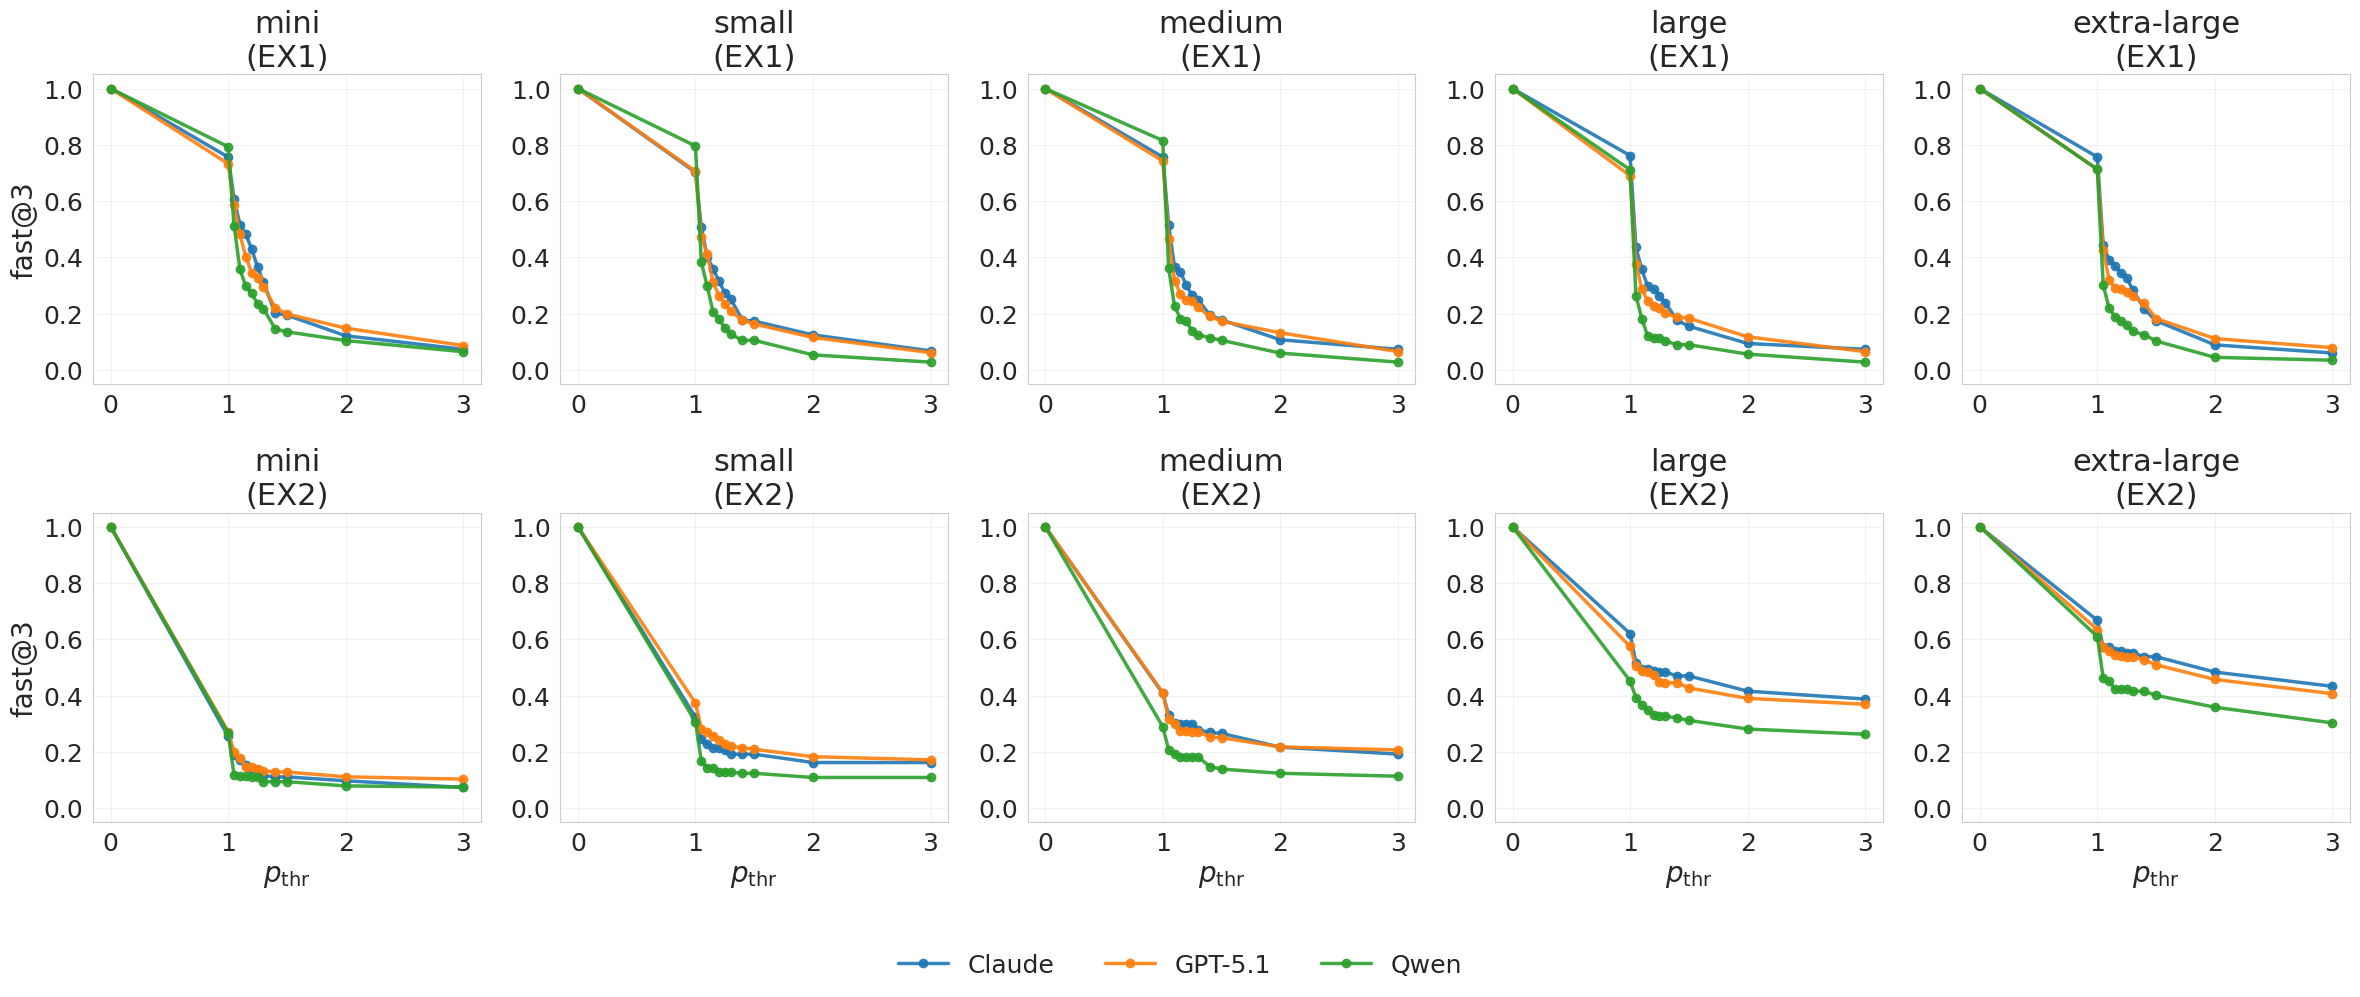

In [22]:
print("="*80)
print("Start Plotting: Fast@3 vs p_thr (main paper flgure)")
print("="*80)

plot_metric_vs_p_thr(
    metric_name='Fast_at_k_avg',
    ylabel='fast@3',
    title_prefix='fast@3',
    filename='figure_fast_at_k_all_datasets.pdf'
)

Start Plotting: Speedup@3 vs p_thr (main paper flgure)
✓ Figure saved: ../../analysis_summaries/figures/figure_speedup_at_k_all_datasets.pdf


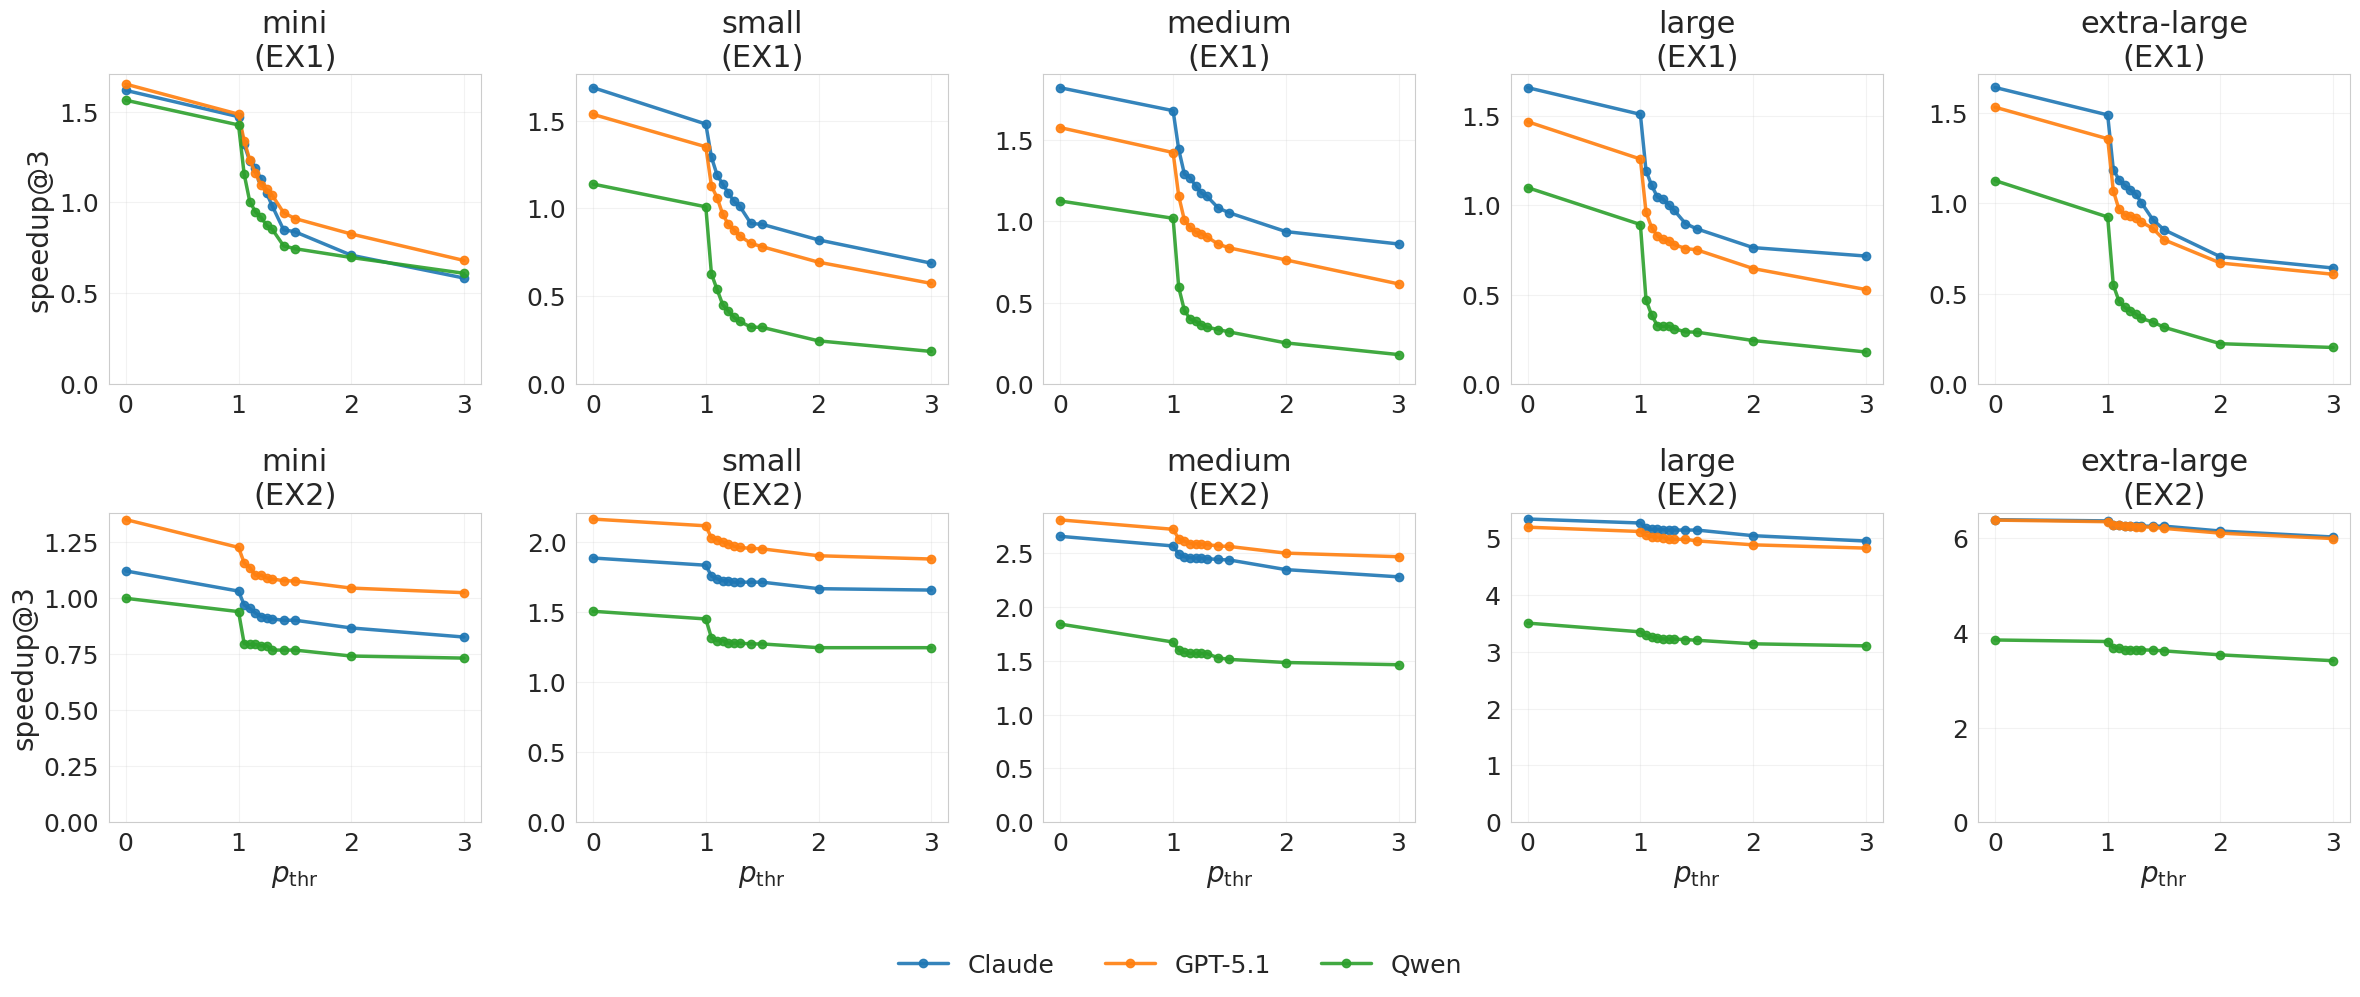

In [23]:
print("="*80)
print("Start Plotting: Speedup@3 vs p_thr (main paper flgure)")
print("="*80)

plot_metric_vs_p_thr(
    metric_name='Speedup_at_k_avg',
    ylabel='speedup@3',
    title_prefix='speedup@3',
    filename='figure_speedup_at_k_all_datasets.pdf'
)

## 附录图：按 Difficulty 分层（Table G）

绘制不同难度级别的 Fast@3 和 Speedup@3

In [8]:
def plot_by_difficulty(metric_name='Fast_at_k_avg',
                       ylabel='Fast@3',
                       title_prefix='Fast@3',
                       filename_prefix='figure_fast_at_k_by_difficulty'):
    """
    按 difficulty 分层画图，使用 Table G
    每个 (EX, dataset_size) 一张图，4条线 (d1, d2, d3, d4)
    
    Args:
        metric_name: 指标列名
        ylabel: Y轴标签
        title_prefix: 标题前缀
        filename_prefix: 文件名前缀
    """
    
    # 颜色方案
    DIFFICULTY_COLORS = {
        'd1': '#1f77b4',  # 蓝色
        'd2': '#ff7f0e',  # 橙色
        'd3': '#2ca02c',  # 绿色
        'd4': '#d62728'   # 红色
    }
    
    DIFFICULTY_LABELS = {
        'd1': 'Difficulty 1 (Easy)',
        'd2': 'Difficulty 2',
        'd3': 'Difficulty 3',
        'd4': 'Difficulty 4 (Hard)'
    }
    
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            # 读取 Table G
            table_g_file = f"{TABLE_DIR}/table_g_difficulty_k3_{ex}_{ds}.csv"
            
            if not os.path.exists(table_g_file):
                print(f"⚠️  文件不存在: {table_g_file}")
                continue
            
            df_g = pd.read_csv(table_g_file)
            
            # 对于 EX2，只保留 threads=16 的数据
            if ex == 'EX2':
                df_g = df_g[df_g['threads'] == 16.0]
            
            # 只画 claude model（或选择一个代表性 model）
            # 如果想画所有 model，需要用 subplot
            model = 'claude'
            df_model = df_g[df_g['model'] == model]
            
            if len(df_model) == 0:
                continue
            
            # 创建图
            fig, ax = plt.subplots(figsize=(8, 6))
            
            # 为每个 difficulty 画一条线
            for difficulty in ['d1', 'd2', 'd3', 'd4']:
                df_diff = df_model[df_model['difficulty'] == difficulty].sort_values('p_thr')
                
                if len(df_diff) == 0:
                    continue
                
                ax.plot(df_diff['p_thr'],
                       df_diff[metric_name],
                       marker='o',
                       linewidth=2,
                       markersize=6,
                       label=DIFFICULTY_LABELS[difficulty],
                       color=DIFFICULTY_COLORS[difficulty],
                       alpha=0.8)
            
            ax.set_title(f'{title_prefix} by Difficulty ({ex}, {ds}, {MODEL_LABELS[model]})', fontsize=14)
            ax.set_xlabel('p_thr', fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', framealpha=0.9)
            
            if metric_name == 'Fast_at_k_avg':
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)
            
            plt.tight_layout()
            
            # 保存
            output_path = f"{FIGURE_DIR}/{filename_prefix}_{ex}_{ds}.pdf"
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"  ✓ {output_path}")
            plt.close()

print("✓ Difficulty 分层画图函数定义完成")

def plot_by_difficulty_grid(metric_name='Fast_at_k_avg',
                            ylabel='Fast@3',
                            title_prefix='Fast@3 by Difficulty',
                            filename='figure_fast_at_k_by_difficulty_grid.pdf',
                            model='claude',
                            ex_versions=('EX1', 'EX2'),
                            dataset_sizes=('mini', 'small', 'medium', 'large', 'extra-large'),
                            ex2_threads_keep=16.0):
    """
    按 difficulty 分层画图（使用 Table G），做成 2×5 的大图：
      - 第一行: EX1 的 5 个 dataset size
      - 第二行: EX2 的 5 个 dataset size
    每个子图 4 条线 (d1, d2, d3, d4)，全局 legend 平铺底部。
    只画一个指定 model（默认 claude）。

    输入: table_g_difficulty_k3_{EX}_{dataset_size}.csv
    输出: 一个 PDF 大图
    """

    # ---- Style (bigger fonts) ----
    TITLE_FS = 22
    SUBTITLE_FS = 20
    LABEL_FS = 20
    TICK_FS = 18
    LINE_W = 2.5
    MARK_SZ = 6

    # ---- Colors/labels ----
    DIFFICULTY_COLORS = {
        'd1': '#1f77b4',
        'd2': '#ff7f0e',
        'd3': '#2ca02c',
        'd4': '#d62728',
    }
    DIFFICULTY_LABELS = {
        'd1': 'd1',
        'd2': 'd2',
        'd3': 'd3',
        'd4': 'd4',
    }
    DIFFICULTIES = ['d1', 'd2', 'd3', 'd4']

    n_rows = len(ex_versions)
    n_cols = len(dataset_sizes)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10), sharex=False, sharey=False)

    # optional: global title (can comment out if professor dislikes)
    # fig.suptitle(f'{title_prefix} ({MODEL_LABELS.get(model, model)})', fontsize=24, y=0.995)

    legend_handles = {}

    for row_idx, ex in enumerate(ex_versions):
        for col_idx, ds in enumerate(dataset_sizes):
            ax = axes[row_idx, col_idx]

            table_g_file = f"{TABLE_DIR}/table_g_difficulty_k3_{ex}_{ds}.csv"
            if not os.path.exists(table_g_file):
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=LABEL_FS)
                ax.set_title(f'{ds}\n({ex})', fontsize=SUBTITLE_FS, pad=6)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            df_g = pd.read_csv(table_g_file)

            # EX2: keep a representative thread count (you can change ex2_threads_keep)
            if ex == 'EX2' and 'threads' in df_g.columns:
                df_g = df_g[df_g['threads'] == float(ex2_threads_keep)]

            # filter model
            df_m = df_g[df_g['model'] == model]
            if len(df_m) == 0:
                ax.text(0.5, 0.5, 'No Model Data', ha='center', va='center', fontsize=LABEL_FS)
                ax.set_title(f'{ds}\n({ex})', fontsize=SUBTITLE_FS, pad=6)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            # plot 4 difficulty lines
            for diff in DIFFICULTIES:
                df_d = df_m[df_m['difficulty'] == diff].sort_values('p_thr')
                if len(df_d) == 0:
                    continue

                line, = ax.plot(
                    df_d['p_thr'],
                    df_d[metric_name],
                    marker='o',
                    linewidth=LINE_W,
                    markersize=MARK_SZ,
                    color=DIFFICULTY_COLORS[diff],
                    alpha=0.9,
                    label=DIFFICULTY_LABELS[diff]
                )

                # store for global legend
                if diff not in legend_handles:
                    legend_handles[diff] = line

            # titles / ticks / grid
            ax.set_title(f'{ds}\n({ex})', fontsize=SUBTITLE_FS, pad=6)
            ax.grid(True, alpha=0.25)
            ax.tick_params(axis='both', labelsize=TICK_FS)

            # only bottom row x-label
            if row_idx == n_rows - 1:
                ax.set_xlabel(r'$p_{\mathrm{thr}}$', fontsize=LABEL_FS)
            else:
                ax.set_xlabel('')

            # only left col y-label
            if col_idx == 0:
                ax.set_ylabel(ylabel, fontsize=LABEL_FS)
            else:
                ax.set_ylabel('')

            # y-limits
            if metric_name == 'Fast_at_k_avg':
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)

    # ---- Global legend at bottom (flat) ----
    handles = [legend_handles[d] for d in DIFFICULTIES if d in legend_handles]
    labels = [DIFFICULTY_LABELS[d] for d in DIFFICULTIES if d in legend_handles]

    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=len(labels),
        fontsize=18,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    # layout: leave space for legend
    plt.tight_layout(rect=[0, 0.06, 1, 1])

    output_path = f"{FIGURE_DIR}/{filename}"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved: {output_path}")
    plt.show()

print("grid configuration setup")

✓ Difficulty 分层画图函数定义完成
grid configuration setup


✓ Figure saved: ../../analysis_summaries/figures/figure_fast_at_k_by_difficulty_grid_claude.pdf


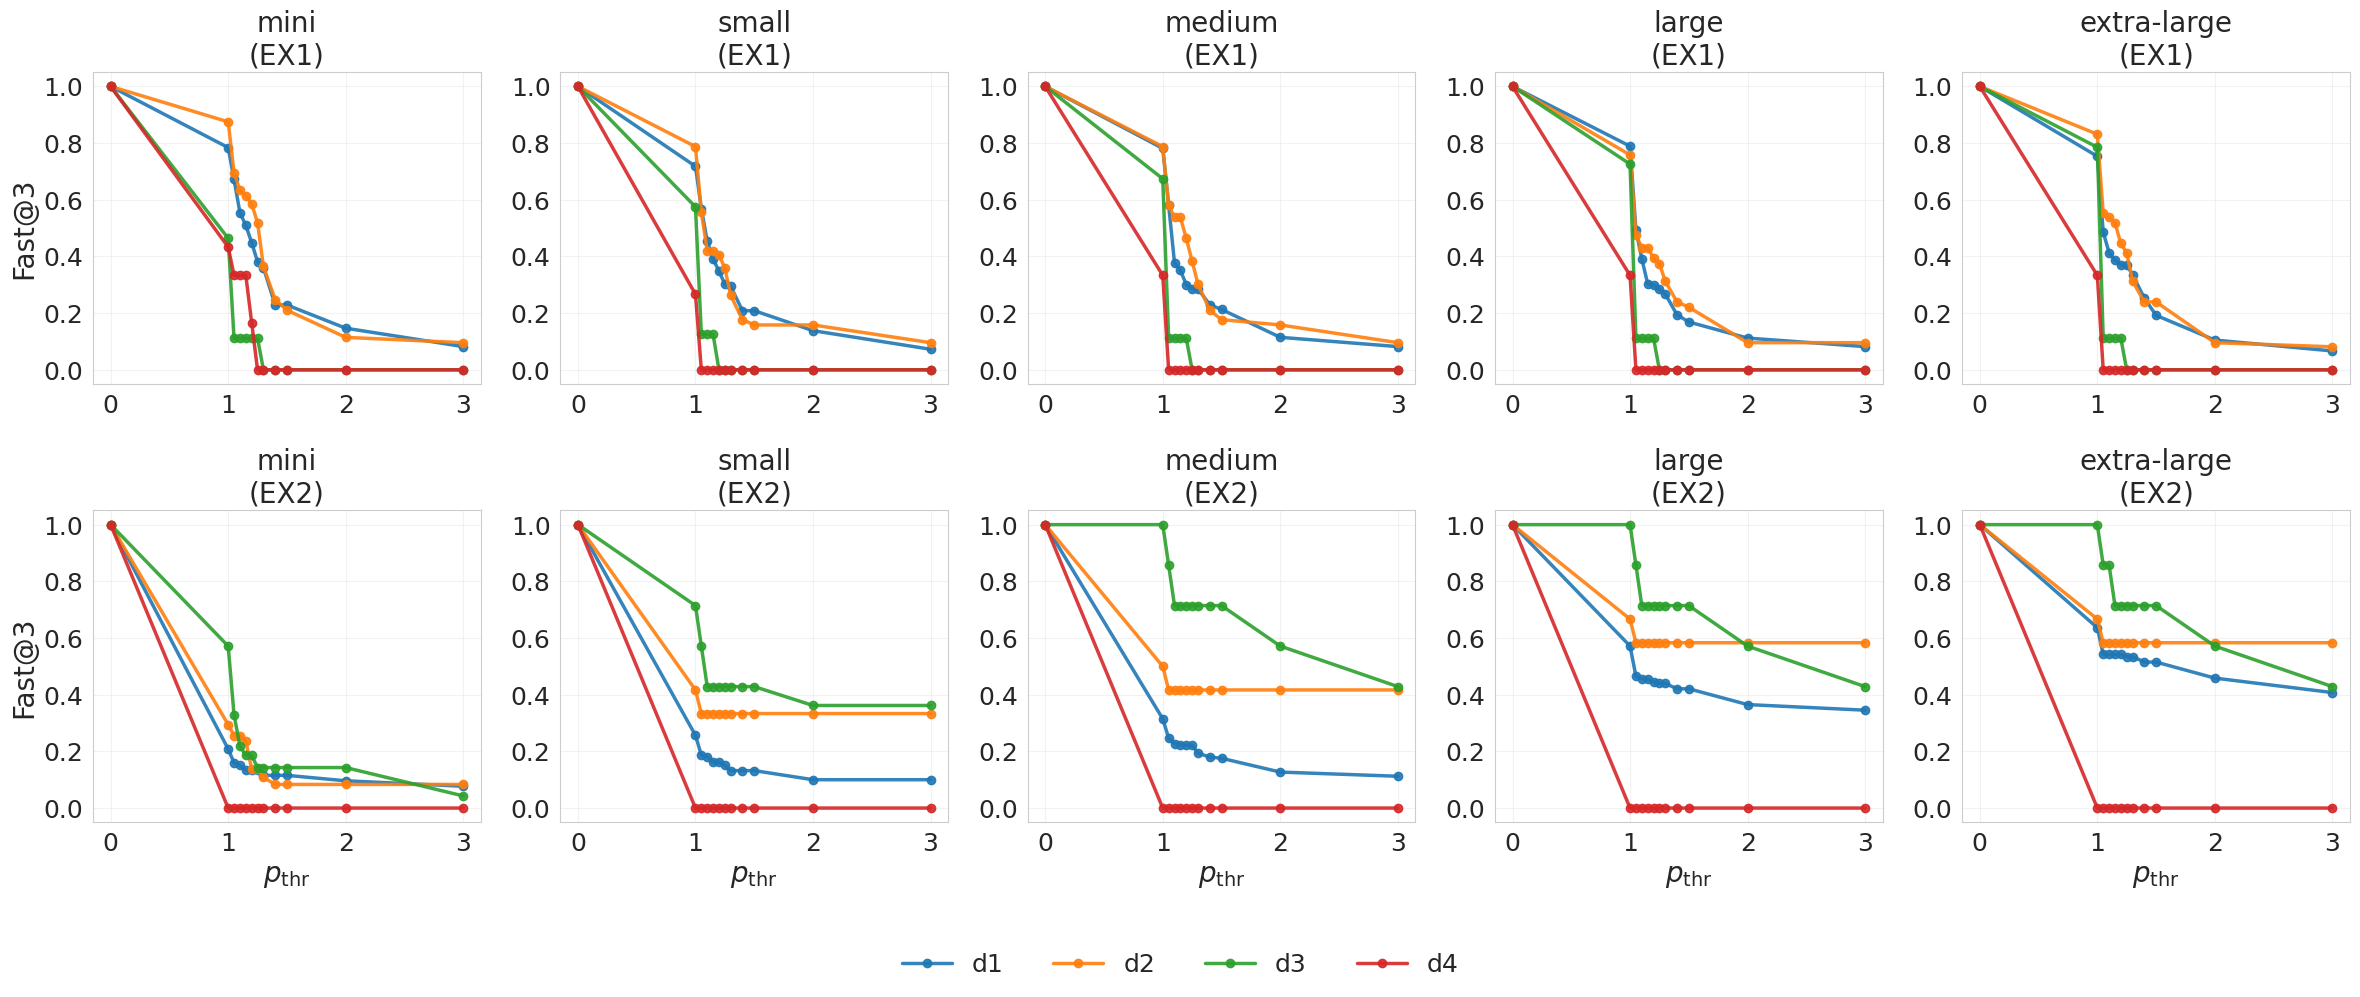

In [9]:
plot_by_difficulty_grid(
    metric_name='Fast_at_k_avg',
    ylabel='Fast@3',
    title_prefix='Fast@3 by Difficulty',
    filename='figure_fast_at_k_by_difficulty_grid_claude.pdf',
    model='claude',
    ex2_threads_keep=16.0
)

In [ ]:

print("="*80)
print("生成附录图: Fast@3 by Difficulty")
print("="*80)

plot_by_difficulty(
    metric_name='Fast_at_k_avg',
    ylabel='fast@3',
    title_prefix='fast@3',
    filename_prefix='figure_fast_at_k_by_difficulty'
)

print("\n" + "="*80)
print("生成附录图: Speedup@3 by Difficulty")
print("="*80)

plot_by_difficulty(
    metric_name='Speedup_at_k_avg',
    ylabel='Speedup@3',
    title_prefix='Speedup@3',
    filename_prefix='figure_speedup_at_k_by_difficulty'
)

✓ Difficulty 分层画图函数定义完成
grid configuration setup


## 附录图：按 Motif 分层（Table F）

绘制不同 computational motif 的 Fast@3 和 Speedup@3（选择代表性 motif）

In [ ]:
def plot_by_motif(metric_name='Fast_at_k_avg',
                  ylabel='Fast@3',
                  title_prefix='Fast@3',
                  filename_prefix='figure_fast_at_k_by_motif',
                  selected_motifs=None):
    """
    按 motif 分层画图，使用 Table F
    
    Args:
        metric_name: 指标列名
        ylabel: Y轴标签
        title_prefix: 标题前缀
        filename_prefix: 文件名前缀
        selected_motifs: 选择要画的 motif 列表（None 表示全部）
    """
    
    # 如果没有指定，选择几个代表性的 motif
    if selected_motifs is None:
        selected_motifs = [
            'dense_linear_algebra',
            'stencil_computations',
            'image_and_video_processing',
            'sparse_linear_algebra',
            'graph_algorithms'
        ]
    
    # 为每个 motif 分配颜色
    motif_colors = plt.cm.tab10(range(len(selected_motifs)))
    MOTIF_COLORS = dict(zip(selected_motifs, motif_colors))
    
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            # 读取 Table F
            table_f_file = f"{TABLE_DIR}/table_f_motif_k3_{ex}_{ds}.csv"
            
            if not os.path.exists(table_f_file):
                print(f"⚠️  文件不存在: {table_f_file}")
                continue
            
            df_f = pd.read_csv(table_f_file)
            
            # 对于 EX2，只保留 threads=16 的数据
            if ex == 'EX2':
                df_f = df_f[df_f['threads'] == 16.0]
            
            # 只画 claude model
            model = 'claude'
            df_model = df_f[df_f['model'] == model]
            
            if len(df_model) == 0:
                continue
            
            # 创建图
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # 为每个选中的 motif 画一条线
            for motif in selected_motifs:
                df_motif = df_model[df_model['motif'] == motif].sort_values('p_thr')
                
                if len(df_motif) == 0:
                    continue
                
                # 美化 motif 名称（用于图例）
                motif_label = motif.replace('_', ' ').title()
                
                ax.plot(df_motif['p_thr'],
                       df_motif[metric_name],
                       marker='o',
                       linewidth=2,
                       markersize=5,
                       label=motif_label,
                       color=MOTIF_COLORS[motif],
                       alpha=0.8)
            
            ax.set_title(f'{title_prefix} by Motif ({ex}, {ds}, {MODEL_LABELS[model]})', fontsize=14)
            ax.set_xlabel('p_thr', fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', framealpha=0.9, fontsize=9)
            
            if metric_name == 'Fast_at_k_avg':
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)
            
            plt.tight_layout()
            
            # 保存
            output_path = f"{FIGURE_DIR}/{filename_prefix}_{ex}_{ds}.pdf"
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"  ✓ {output_path}")
            plt.close()

print("✓ Motif 分层画图函数定义完成")

✓ Motif 分层画图函数定义完成


In [33]:
print("="*80)
print("生成附录图: Fast@3 by Motif (选择代表性 motif)")
print("="*80)

plot_by_motif(
    metric_name='Fast_at_k_avg',
    ylabel='Fast@3',
    title_prefix='Fast@3',
    filename_prefix='figure_fast_at_k_by_motif'
)

print("\n" + "="*80)
print("生成附录图: Speedup@3 by Motif (选择代表性 motif)")
print("="*80)

plot_by_motif(
    metric_name='Speedup_at_k_avg',
    ylabel='Speedup@3',
    title_prefix='Speedup@3',
    filename_prefix='figure_speedup_at_k_by_motif'
)

生成附录图: Fast@3 by Motif (选择代表性 motif)
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX1_mini.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX1_small.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX1_medium.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX1_large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX1_extra-large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX2_mini.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX2_small.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX2_medium.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX2_large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_EX2_extra-large.pdf

生成附录图: Speedup@3 by Motif (选择代表性 motif)
  ✓ ../../analysis_summaries/figures/figure_speedup_at_k_by_motif_EX1_mini.pdf
  ✓ ../../analysis_summaries/figures/figure_speedup_at_k_by_m

In [10]:
def plot_by_motif_with_difficulty_filter(
                  metric_name='Fast_at_k',
                  ylabel='Fast@3',
                  title_prefix='Fast@3',
                  filename_prefix='figure_fast_at_k_by_motif',
                  selected_motifs=None,
                  difficulty_filter=None,
                  model='claude'):
    """
    按 motif 分层画图，支持 difficulty 筛选（使用 Table D）
    
    Args:
        metric_name: 指标列名 ('Fast_at_k' 或 'Speedup_at_k')
        ylabel: Y轴标签
        title_prefix: 标题前缀
        filename_prefix: 文件名前缀
        selected_motifs: 选择要画的 motif 列表（None 表示全部）
        difficulty_filter: 筛选特定 difficulty（None=全部, 或 'd1', 'd2', 'd3', 'd4'）
        model: 选择要画的 model（默认 'claude'）
    """
    
    # 如果没有指定，选择几个代表性的 motif
    if selected_motifs is None:
        selected_motifs = [
            'dense_linear_algebra',
            'stencil_computations',
            'image_and_video_processing',
            'sparse_linear_algebra',
            'graph_algorithms'
        ]
    
    # 为每个 motif 分配颜色
    motif_colors = plt.cm.tab10(range(len(selected_motifs)))
    MOTIF_COLORS = dict(zip(selected_motifs, motif_colors))
    
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            # 读取 Table D（包含 difficulty 信息）
            table_d_file = f"{TABLE_DIR}/table_d_per_benchmark_k3_{ex}_{ds}.csv"
            
            if not os.path.exists(table_d_file):
                print(f"⚠️  文件不存在: {table_d_file}")
                continue
            
            df_d = pd.read_csv(table_d_file)
            
            # 对于 EX2，只保留 threads=16 的数据
            if ex == 'EX2':
                df_d = df_d[df_d['threads'] == 16.0]
            
            # 筛选 model
            df_model = df_d[df_d['model'] == model]
            
            # 筛选 difficulty（如果指定）
            if difficulty_filter is not None:
                df_model = df_model[df_model['difficulty'] == difficulty_filter]
            
            if len(df_model) == 0:
                continue
            
            # 对每个 (motif, p_thr) 做平均（因为一个 motif 可能有多个 benchmark）
            df_agg = df_model.groupby(['motif', 'p_thr']).agg({
                metric_name: 'mean'
            }).reset_index()
            
            # 创建图
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # 为每个选中的 motif 画一条线
            for motif in selected_motifs:
                df_motif = df_agg[df_agg['motif'] == motif].sort_values('p_thr')
                
                if len(df_motif) == 0:
                    continue
                
                # 美化 motif 名称（用于图例）
                motif_label = motif.replace('_', ' ').title()
                
                ax.plot(df_motif['p_thr'],
                       df_motif[metric_name],
                       marker='o',
                       linewidth=2,
                       markersize=5,
                       label=motif_label,
                       color=MOTIF_COLORS[motif],
                       alpha=0.8)
            
            # 标题中包含 difficulty 信息
            diff_str = f", {difficulty_filter}" if difficulty_filter else ", All Difficulties"
            ax.set_title(f'{title_prefix} by Motif ({ex}, {ds}, {MODEL_LABELS[model]}{diff_str})', 
                        fontsize=14)
            ax.set_xlabel('p_thr', fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', framealpha=0.9, fontsize=9)
            
            if 'Fast' in metric_name:
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)
            
            plt.tight_layout()
            
            # 保存（文件名中包含 difficulty）
            diff_suffix = f"_{difficulty_filter}" if difficulty_filter else "_all_diff"
            output_path = f"{FIGURE_DIR}/{filename_prefix}{diff_suffix}_{ex}_{ds}.pdf"
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"  ✓ {output_path}")
            plt.close()

print("✓ 支持 Difficulty 筛选的 Motif 画图函数定义完成")

✓ 支持 Difficulty 筛选的 Motif 画图函数定义完成


In [11]:
print("="*80)
print("生成附录图: Fast@3 by Motif (支持 Difficulty 筛选)")
print("="*80)

# 示例 1: 只画 difficulty=d1 的数据
print("\n示例 1: 只画 difficulty=d1")
plot_by_motif_with_difficulty_filter(
    metric_name='Fast_at_k',
    ylabel='Fast@3',
    title_prefix='Fast@3',
    filename_prefix='figure_fast_at_k_by_motif',
    difficulty_filter='d1'  # 只画 d1
)

# 示例 2: 只画 difficulty=d2 的数据
print("\n示例 2: 只画 difficulty=d2")
plot_by_motif_with_difficulty_filter(
    metric_name='Fast_at_k',
    ylabel='Fast@3',
    title_prefix='Fast@3',
    filename_prefix='figure_fast_at_k_by_motif',
    difficulty_filter='d2'  # 只画 d2
)

# 示例 3: 画所有 difficulty 的平均
print("\n示例 3: 画所有 difficulty 的平均")
plot_by_motif_with_difficulty_filter(
    metric_name='Fast_at_k',
    ylabel='Fast@3',
    title_prefix='Fast@3',
    filename_prefix='figure_fast_at_k_by_motif',
    difficulty_filter=None  # 全部 difficulty
)

print("\n" + "="*80)
print("💡 提示: 你可以修改 difficulty_filter 参数来选择:")
print("  - 'd1': 只画 Difficulty 1 (Easy)")
print("  - 'd2': 只画 Difficulty 2")
print("  - 'd3': 只画 Difficulty 3")
print("  - 'd4': 只画 Difficulty 4 (Hard)")
print("  - None: 画所有 difficulty 的平均")
print("="*80)

生成附录图: Fast@3 by Motif (支持 Difficulty 筛选)

示例 1: 只画 difficulty=d1
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX1_mini.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX1_small.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX1_medium.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX1_large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX1_extra-large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX2_mini.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX2_small.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX2_medium.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX2_large.pdf
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d1_EX2_extra-large.pdf

示例 2: 只画 difficulty=d2
  ✓ ../../analysis_summaries/figures/figure_fast_at_k_by_motif_d2_EX1_mini.pdf
  ✓ ../../analysis_

## 高级图：Motif × Difficulty 对比

为特定 motif 画不同 difficulty 的对比图

def plot_motif_by_difficulty_comparison(
                  metric_name='Fast_at_k',
                  ylabel='Fast@3',
                  title_prefix='Fast@3',
                  filename_prefix='figure_fast_at_k_motif_diff_comparison',
                  selected_motif='dense_linear_algebra',
                  model='claude'):
    """
    为一个 motif，画不同 difficulty 的对比图
    
    Args:
        metric_name: 指标列名
        ylabel: Y轴标签
        title_prefix: 标题前缀
        filename_prefix: 文件名前缀
        selected_motif: 要分析的 motif
        model: 模型名称
    """
    
    DIFFICULTY_COLORS = {
        'd1': '#1f77b4',  # 蓝色
        'd2': '#ff7f0e',  # 橙色
        'd3': '#2ca02c',  # 绿色
        'd4': '#d62728'   # 红色
    }
    
    DIFFICULTY_LABELS = {
        'd1': 'Difficulty 1 (Easy)',
        'd2': 'Difficulty 2',
        'd3': 'Difficulty 3',
        'd4': 'Difficulty 4 (Hard)'
    }
    
    for ex in EX_VERSIONS:
        for ds in DATASET_SIZES:
            # 读取 Table D
            table_d_file = f"{TABLE_DIR}/table_d_per_benchmark_k3_{ex}_{ds}.csv"
            
            if not os.path.exists(table_d_file):
                continue
            
            df_d = pd.read_csv(table_d_file)
            
            # 筛选条件
            if ex == 'EX2':
                df_d = df_d[df_d['threads'] == 16.0]
            
            df_model = df_d[(df_d['model'] == model) & (df_d['motif'] == selected_motif)]
            
            if len(df_model) == 0:
                continue
            
            # 按 (difficulty, p_thr) 聚合
            df_agg = df_model.groupby(['difficulty', 'p_thr']).agg({
                metric_name: 'mean'
            }).reset_index()
            
            # 创建图
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # 为每个 difficulty 画一条线
            for difficulty in ['d1', 'd2', 'd3', 'd4']:
                df_diff = df_agg[df_agg['difficulty'] == difficulty].sort_values('p_thr')
                
                if len(df_diff) == 0:
                    continue
                
                ax.plot(df_diff['p_thr'],
                       df_diff[metric_name],
                       marker='o',
                       linewidth=2,
                       markersize=6,
                       label=DIFFICULTY_LABELS[difficulty],
                       color=DIFFICULTY_COLORS[difficulty],
                       alpha=0.8)
            
            motif_label = selected_motif.replace('_', ' ').title()
            ax.set_title(f'{title_prefix} for {motif_label} by Difficulty ({ex}, {ds}, {MODEL_LABELS[model]})', 
                        fontsize=14)
            ax.set_xlabel('p_thr', fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', framealpha=0.9)
            
            if 'Fast' in metric_name:
                ax.set_ylim(-0.05, 1.05)
            else:
                ax.set_ylim(bottom=0)
            
            plt.tight_layout()
            
            # 保存
            output_path = f"{FIGURE_DIR}/{filename_prefix}_{selected_motif}_{ex}_{ds}.pdf"
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"  ✓ {output_path}")
            plt.close()

print("✓ Motif × Difficulty 对比图函数定义完成")

In [ ]:
print("="*80)
print("高级图: 为特定 Motif 画不同 Difficulty 的对比")
print("="*80)

# 示例: 为 dense_linear_algebra motif 画 4 条难度线
print("\n为 'dense_linear_algebra' 画不同 difficulty 的对比:")
plot_motif_by_difficulty_comparison(
    metric_name='Fast_at_k',
    ylabel='Fast@3',
    title_prefix='Fast@3',
    filename_prefix='figure_fast_at_k_motif_diff_comparison',
    selected_motif='dense_linear_algebra',
    model='claude'
)

print("\n💡 提示: 你可以修改 selected_motif 参数来分析其他 motif:")
print("  - 'dense_linear_algebra'")
print("  - 'stencil_computations'")
print("  - 'graph_algorithms'")
print("  - 'sparse_linear_algebra'")
print("  - 'image_and_video_processing'")
print("  等等...")
print("="*80)

In [34]:
print("="*80)
print("所有图片生成完成！")
print("="*80)

print(f"""
✅ 图片保存位置: {FIGURE_DIR}/

📊 生成的图片清单:

**主文图 (Table E - 整体平均)**:
  1. figure_fast_at_k_all_datasets.pdf
     - 2行5列，展示所有 dataset_size 的 Fast@3 vs p_thr
  
  2. figure_speedup_at_k_all_datasets.pdf
     - 2行5列，展示所有 dataset_size 的 Speedup@3 vs p_thr

**附录图 (Table G - Difficulty 分层)**:
  3-12. figure_fast_at_k_by_difficulty_{EX}_{dataset_size}.pdf
     - 每个 (EX, dataset_size) 一张图，共 10 张
     - 4条线: d1, d2, d3, d4
  
  13-22. figure_speedup_at_k_by_difficulty_{EX}_{dataset_size}.pdf
     - 每个 (EX, dataset_size) 一张图，共 10 张

**附录图 (Table F - Motif 分层)**:
  23-32. figure_fast_at_k_by_motif_{EX}_{dataset_size}.pdf
     - 每个 (EX, dataset_size) 一张图，共 10 张
     - 5条代表性 motif 的线
  
  33-42. figure_speedup_at_k_by_motif_{EX}_{dataset_size}.pdf
     - 每个 (EX, dataset_size) 一张图，共 10 张

**总计: 约 42 张图**

🎯 使用建议:
  - 主文用: figure_fast_at_k_all_datasets.pdf 和 figure_speedup_at_k_all_datasets.pdf
  - 附录用: 按 difficulty 和 motif 分层的图
  - 所有图片均为 PDF 格式（矢量图），适合论文使用
""")

print("="*80)

所有图片生成完成！


NameError: name 'EX' is not defined

In [ ]:
## (可选) k 敏感性分析 - 为附录生成多个 k 的 Table D/E

print("="*80)
print("(可选) k 敏感性分析")
print("="*80)

print("""
如果需要在附录中展示 k 敏感性（Fast@k 随 k 变化的曲线），
可以取消下面代码的注释并运行:
""")

# K_SENSITIVITY = [1, 3, 5, 10]
# 
# for k_val in K_SENSITIVITY:
#     print(f"\n生成 k={k_val} 的 Table D/E...")
#     
#     table_d_k = compute_table_d(df, P_THR_MAIN, k=k_val)
#     table_e_k = compute_table_e(table_d_k)
#     
#     # 保存
#     for ex in EX_VERSIONS:
#         for ds in DATASET_SIZES:
#             # Table D
#             subset_d = table_d_k[(table_d_k['ex'] == ex) & (table_d_k['dataset_size'] == ds)]
#             if len(subset_d) > 0:
#                 output_file = f"{OUTPUT_DIR}/appendix_table_d_k{k_val}_{ex}_{ds}.csv"
#                 subset_d.to_csv(output_file, index=False)
#             
#             # Table E
#             subset_e = table_e_k[(table_e_k['ex'] == ex) & (table_e_k['dataset_size'] == ds)]
#             if len(subset_e) > 0:
#                 output_file = f"{OUTPUT_DIR}/appendix_table_e_k{k_val}_{ex}_{ds}.csv"
#                 subset_e.to_csv(output_file, index=False)
#     
#     print(f"  ✓ k={k_val} 完成")

print("\n如果需要 k 敏感性分析，取消上面注释并运行即可。")

In [ ]:
print("="*80)
print("所有表格生成完成！")
print("="*80)

print(f"""
✅ 已生成 Table A, B, C, D, E，所有文件位于: {OUTPUT_DIR}/

📊 文件清单:

**主文表格 (k=3):**
  - Table A (trial-level): 10 个文件 (2 EX × 5 dataset_size)
  - Table B (per-benchmark): 10 个文件
  - Table C (paper-level): 30 个文件 (3 grouping × 2 EX × 5 dataset_size)
  - Table D (per-benchmark × p): 10 个文件
  - Table E (paper-level × p): 10 个文件
  
**总计: ~70 个 CSV 文件**

🎯 使用指南:

1. **画主文图** (Fast@k vs p_thr, Speedup@k vs p_thr):
   - 读取 Table E
   - 固定 k=3, 选择 dataset_size (如 medium)
   - X 轴: p_thr, Y 轴: Fast_at_k_avg / Speedup_at_k_avg
   - 每条线: 一个 model, 分面: EX1/EX2

2. **分层分析** (motif / difficulty):
   - 使用 Table C 的 motif / difficulty 版本
   - 或者从 Table D 用 motif/difficulty 做 groupby

3. **Debug / Error Analysis**:
   - 使用 Table A 查看具体的 trial
   - 使用 Table D 的 c_p 和 pass_rate 诊断问题

4. **k 敏感性** (附录):
   - 取消上面 k sensitivity 代码的注释
   - 生成 k ∈ {{1,3,5,10}} 的 Table D/E
   - 画 Fast@k vs k 曲线 (固定 p_thr)

💡 下一步建议:
  - 运行 notebook 生成所有表格
  - 开始绘制论文图表 (Step 3: Draw Figures)
  - 如有问题，回到 Sanity Checks 检查数据质量
""")

print("="*80)

In [12]:
print("="*80)
print("所有 Sanity Checks 完成!")
print("="*80)

print("""
如果所有检查都通过，说明数据质量良好，可以进行后续分析。

如果有警告或错误，需要根据具体情况：
1. 唯一键重复 → 检查数据生成逻辑，可能有 concat 重复
2. Trial 数量不对 → 检查是否有 benchmark 缺测试或者重复
3. Baseline 不稳定 → 考虑重新聚合 baseline (取均值)
4. NC 但有测量值 → 数据逻辑错误，需要修复
5. Correctness 定义不一致 → 检查 checker 输出格式
6. Dataset coverage 不均 → 选择 coverage 最好的 dataset_size

下一步建议：
- 如果所有检查通过，可以开始写 Pass Rate, Fast@k, Speedup@k 分析
- 如果有问题，先修复数据再继续
""")


所有 Sanity Checks 完成!

如果所有检查都通过，说明数据质量良好，可以进行后续分析。

如果有警告或错误，需要根据具体情况：
1. 唯一键重复 → 检查数据生成逻辑，可能有 concat 重复
2. Trial 数量不对 → 检查是否有 benchmark 缺测试或者重复
3. Baseline 不稳定 → 考虑重新聚合 baseline (取均值)
4. NC 但有测量值 → 数据逻辑错误，需要修复
5. Correctness 定义不一致 → 检查 checker 输出格式
6. Dataset coverage 不均 → 选择 coverage 最好的 dataset_size

下一步建议：
- 如果所有检查通过，可以开始写 Pass Rate, Fast@k, Speedup@k 分析
- 如果有问题，先修复数据再继续



### Step 3: Draw Figures

In [20]:
df_a = pd.read_csv("../../analysis_summaries/tables/table_a_trial_level_EX1_medium.csv")
df_b = pd.read_csv("../../analysis_summaries/tables/table_b_per_benchmark_EX1_medium.csv")
df_c = pd.read_csv("../../analysis_summaries/tables/table_c_overall_EX1_medium.csv")
print(f'df.columns: {df_a.columns}')
print(f'df.columns: {df_b.columns}')
print(f'df.columns: {df_c.columns}')

df.columns: Index(['benchmark', 'ex', 'model', 'trial_id', 'dataset_size', 'compiler',
       'threads', 'suite', 'difficulty', 'motif', 'compile_status',
       'correctness', 'correctness_tested', 'baseline_kernel_mean_s',
       'baseline_total_mean_s', 'kernel_mean_s', 'total_mean_s',
       'kernel_speedup', 'total_speedup', 'warmup_runs', 'measure_runs',
       'hint_key', 'success_rate', 'checker', 'correctness_message',
       'executable_path'],
      dtype='object')
df.columns: Index(['benchmark', 'ex', 'model', 'dataset_size', 'threads', 'suite',
       'difficulty', 'motif', 'pass_rate', 'best_N', 'MeanT', 'c_1.0', 'c_1.1',
       'c_1.5', 'c_2.0', 'N'],
      dtype='object')
df.columns: Index(['ex', 'model', 'dataset_size', 'threads', 'grouping', 'group_value',
       'pass_rate', 'best_N', 'MeanT', 'c_1.0', 'c_1.1', 'c_1.5', 'c_2.0',
       'n_benchmarks', 'N_total'],
      dtype='object')
